# VOCALS-REx retrieval with pydisort_riccati_jax

`pydisort_riccati_jax` is a **differentiable** forward solver for the 1-D Radiative Transfer Equation in an atmosphere whose single-scattering albedo $\omega(\tau)$ and phase function $g_l(\tau)$ vary **continuously** with optical depth. The ultimate goal is to **retrieve an effective-radius profile $r_e(\tau)$** from VOCALS-REx marine stratocumulus, using the fully differentiable chain

$$ r_e(\tau)\xrightarrow{\;\texttt{miejax\_lite}\;}\big(\omega(\tau),\,\text{Leg\_coeffs}(\tau)\big)\xrightarrow{\;\texttt{pydisort\_riccati\_jax}\;} u^{+}(\tau{=}0,\mu,\phi). $$

It is a companion to [PythonicDISORT](https://pythonic-disort.readthedocs.io/en/latest/) (the eigendecomposition solver), reuses its conventions, and is validated against it (§2b below).

VOCALS stratocumulus has $r_e\approx 4$–$17\,\mu\mathrm{m}$, observed in the MODIS bands 0.645 / 1.64 / **2.13** µm (2.13 µm is the most absorbing, where $\omega<1$ carries the size signal), with $\tau$ up to $\sim30$ over a low-albedo ocean ($\rho\approx0.06$). This notebook assumes that [`miejax_lite`](../../miejax_lite/README.md) is installed (`pip install -e ../miejax_lite`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))
sys.path.insert(0, str(repo_root / 'tests'))   # for _helpers (convergence check)

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from math import pi

from pydisort_riccati_jax import pydisort_riccati_jax, interpolate
from optics_table import build_re_table, select_channel, table_lookup  # miepython (miejax retired)

## 1. Mie optical properties from $r_e(\tau)$

We model an **adiabatic** cloud whose effective radius grows from cloud base ($\tau{=}$ `tau_bot`) toward top. The optics come from a **precomputed $r_e\to(\omega,\text{Leg\_coeffs})$ interpolation table** (`build_re_table` / `table_lookup`): full Mie inside the solver's ODE never finishes compiling, so we tabulate it once over the physical size range and do an $O(1)$, differentiable linear lookup in the hot path. The table is built at high radius-integration resolution for a ripple-free map, over a grid $[2,25]\,\mu$m spanning the VOCALS-REx in-cloud $r_e$ range with margin (design: [`optics_table_map.md`](../../miejax_lite/docs/optics_table_map.md)). We wrap the lookup in the `*_func(tau)` callables the solver expects.

The profile is written so that $r_e^5$ is **affine** in optical depth. The adiabatic law *in optical depth* is $r_e\propto\tau^{1/5}$: $r_e^3\propto\,$LWC versus *geometric height* ($\mathrm{LWC}\propto z$), but the extinction $\beta\propto r_e^2\propto z^{2/3}$ makes $\tau=\int\!\beta\,dz\propto z^{5/3}$, so $\mathrm{LWC}\propto\tau^{3/5}$ and $r_e\propto\tau^{1/5}$ (equivalently the canonical adiabatic $N_d\propto\tau^{1/2}r_e^{-5/2}$). The offset $r_\text{base} \le r_e$ keeps $dr_e/d\tau$ finite.

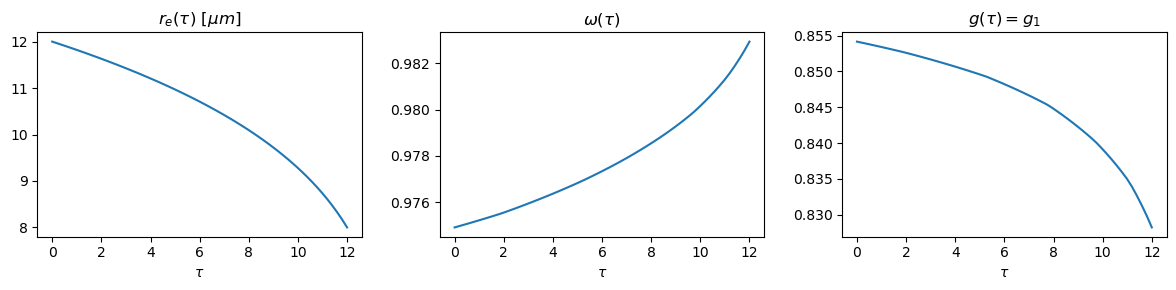

In [2]:
wavelength, v_eff = 2.13, 0.10           # MODIS band 7 (microns), gamma width

tau_bot = 12.0
NQuad, NLeg, NLeg_all = 16, 16, 32       # streams; NLeg_all > NLeg feeds delta-M / TMS

# Optics interpolation table r_e -> (omega, Leg_coeffs), built once (offline,
# high n_radii -> ripple-free). Full Mie inside the ODE never finishes compiling;
# the table makes the optics O(1) and keeps r_e -> (omega, Leg) differentiable
# (table-slope Jacobian). select_channel picks the (single) MODIS band exactly.
opt = select_channel(
    build_re_table([wavelength], 2.0, 25.0, 32, v_eff, n_radii=600, NLeg=NLeg_all), 0)

# Adiabatic r_e(tau): grows from base (tau=tau_bot) to top (tau=0). The adiabatic
# law in OPTICAL DEPTH is r_e ~ tau^(1/5): r_e**3 ~ LWC ~ height z, but the
# extinction ~ r_e**2 makes tau ~ z^(5/3), so r_e ~ tau^(1/5). We make r_e**5 affine
# in tau -> r_e stays >= re_base and dr_e/dtau is finite (no root cusp at base).
re_top, re_base = 12.0, 8.0              # microns (marine Sc: gentle 12->8 um growth)
def r_e_of_tau(tau, re_top=re_top, re_base=re_base):
    return (re_base ** 5 + (re_top ** 5 - re_base ** 5) * (1 - tau / tau_bot)) ** (1 / 5)

def optics(tau, re_top=re_top, re_base=re_base):
    return table_lookup(opt, r_e_of_tau(tau, re_top, re_base))

omega_func      = lambda tau: optics(tau)[0]
Leg_coeffs_func = lambda tau: optics(tau)[1]

tau_plot = jnp.linspace(0, tau_bot, 60)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(tau_plot, [r_e_of_tau(t) for t in tau_plot]); ax[0].set_title(r'$r_e(\tau)\ [\mu m]$')
ax[1].plot(tau_plot, [omega_func(t) for t in tau_plot]); ax[1].set_title(r'$\omega(\tau)$')
ax[2].plot(tau_plot, [Leg_coeffs_func(t)[1] for t in tau_plot]); ax[2].set_title(r'$g(\tau)=g_1$')
for a in ax: a.set_xlabel(r'$\tau$')
plt.tight_layout()

## 2. Forward model: ToA radiance

Solve, then interpolate to the satellite viewing geometry. This `forward` function — radiance as a function of the profile parameters — is the object we will both evaluate and differentiate.

In [3]:
mu0, I0, phi0 = 0.9, 1.0, 0.0           # solar geometry
mu_obs, phi_obs = 0.5, pi               # viewing geometry
BDRF = [0.06]                       # ocean surface

def forward(re_top, re_base):
    om  = lambda tau: optics(tau, re_top, re_base)[0]
    Leg = lambda tau: optics(tau, re_top, re_base)[1]
    mu_arr_pos, flux_up, u0, u_func, _ = pydisort_riccati_jax(
        tau_bot, om, Leg, NQuad, mu0, I0, phi0,
        tol=1e-3, BDRF_Fourier_modes=BDRF,                    # float32-safe production tol
        delta_M_scaling=True, NLeg_all=NLeg_all, NT_cor=True)  # forward-peak fix (OUTSTANDING A)
    return interpolate(u_func, mu_arr_pos)(mu_obs, phi_obs)

I_obs = forward(re_top, re_base)
print('ToA radiance at (mu_obs, phi_obs):', float(I_obs))

ToA radiance at (mu_obs, phi_obs): 0.011461719870567322


### 2b. Validate against PythonicDISORT

`pydisort` solves piecewise-constant layers exactly. Approximating the continuous $\omega(\tau)$, $g_l(\tau)$ profile with more and more layers (midpoint rule) must converge toward the Riccati solution at $O(h^2)$.

This convergence test requires **float64** (`tol=1e-8`); in float32 the solver clamps to `tol=1e-3`, which is too coarse to separate layer-discretization error from ODE tolerance. We enable x64 for this cell only.

In [4]:
import jax
jax.config.update('jax_enable_x64', True)          # tight tol needs float64

from _helpers import multilayer_pydisort_toa_full_phi, PHI_VALUES

N = NQuad // 2
mu_arr_pos, _, _, u_ToA_func, _ = pydisort_riccati_jax(
    tau_bot, omega_func, Leg_coeffs_func, NQuad, mu0, I0, phi0,
    tol=1e-8, BDRF_Fourier_modes=BDRF,
    delta_M_scaling=True, NLeg_all=NLeg_all, NT_cor=True)
u_ric = np.column_stack([np.asarray(u_ToA_func(p))[:N] for p in PHI_VALUES])

def disort_err(NLayers):
    _, _, uf = multilayer_pydisort_toa_full_phi(
        tau_bot, omega_func, Leg_coeffs_func, NLayers, NQuad, NLeg,
        mu0, I0, phi0, BDRF_Fourier_modes=BDRF,
        delta_M_scaling=True, NT_cor=True)
    u_dis = np.column_stack([uf(0, p)[:N] for p in PHI_VALUES])
    return np.max(np.abs(u_dis - u_ric)) / np.max(np.abs(u_ric))

e100, e1000 = disort_err(100), disort_err(1000)
print(f'rel. err  100 layers : {e100:.2e}')
print(f'rel. err 1000 layers : {e1000:.2e}')
print(f'convergence ratio   : {e100 / e1000:.1f}  (~100 expected for O(h^2), 10x refinement)')

jax.config.update('jax_enable_x64', False)          # restore float32 for the rest
x = jnp.array(1.0)
print(x.dtype)                                      # Verify return to float32

rel. err  100 layers : 4.45e-04
rel. err 1000 layers : 4.73e-06
convergence ratio   : 94.2  (~100 expected for O(h^2), 10x refinement)
float32


## 3. Retrieval Jacobian via autodiff

The whole chain — table lookup, Riccati ODE, boundary solve, barycentric $\mu$-interpolation — is JAX-traceable. The sensitivity of the observed radiance to the profile parameters is a single `jax.grad` — no finite differences, no perturbing the solver. This $\partial I/\partial r_e$ is the building block of the retrieval's Gauss–Newton / optimal-estimation step.

*Parameters must enter through `omega_func`/`Leg_coeffs_func`; `tau_bot`, `mu0`, `NQuad` are validated in NumPy and are not differentiable. Finite-difference validation of these gradients lives in the float64 test suite (`pytest -m float64`); in float32 a bare FD is dominated by the solver's tolerance floor, so we don't reproduce it in this demonstration.*

In [5]:
dI_dre_top, dI_dre_base = jax.grad(forward, argnums=(0, 1))(re_top, re_base)
print('dI/d(r_e top)  =', float(dI_dre_top))
print('dI/d(r_e base) =', float(dI_dre_base))

dI/d(r_e top)  = -0.014170760288834572
dI/d(r_e base) = -0.0006917339633218944


## 4. Toward a multi-band retrieval

A real retrieval stacks several MODIS bands (0.645 µm constrains $\tau$, 2.13 µm constrains $r_e$) and minimises a cost $\;J(\boldsymbol\theta)=\sum_b \lVert I_b^{\text{obs}}-F_b(\boldsymbol\theta)\rVert^2 + \text{(prior)}$ over the $r_e(\tau)$ parameters $\boldsymbol\theta$.
 The gradient $\nabla_{\boldsymbol\theta} J$ is assembled from the per-band Jacobians above via `jax.grad`, and fed to an optimiser (`jaxopt`, `optax`, or a hand-rolled Gauss–Newton step). Stacking bands is just building the table at several wavelengths — `build_re_table([0.645, 1.64, 2.13], …)` and `select_channel` per band; a hyperspectral instrument instead builds on a dense, uniform $\lambda$ grid and `slice_wavelength`-interpolates to each channel.

**Performance & scope notes.** The forward model's cost is dominated by the number of adaptive Riccati steps (~35 for $\tau{=}30$); loosen `tol` in the retrieval loop and tighten only for the final fit. The default float32 is adequate against VOCALS measurement noise (10–20 %); enable `jax_enable_x64` for finite-difference gradient checks. Delta-M scaling + the Nakajima–Tanaka TMS correction are **enabled here** (`delta_M_scaling=True, NT_cor=True`, with `NLeg_all=32` untruncated moments) so the forward-peaked-Mie ToA radiance stays non-negative (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A); the reverse-mode Jacobian is exact AD, its memory now bounded by the `lax.scan` over Fourier modes (§H).

In [6]:
import jax
jax.clear_caches()

import vocals_io as vio
import retrieval_oe as roe
import noise_model as nm
from optics_table import build_re_table, select_channel  # miepython (miejax retired)

DATA = ('/home/jovyan/cloud_profile_retrieval/'
        'multispectral-retrieval-using-MODIS/VOCALS_REx_data')
profiles = vio.load_all_profiles(DATA)

# common geometry / discretisation (shared by the idealized AND joint retrievals)
NQuad, NLeg_all, v_eff = 16, 1024, 0.10
mu0, I0, phi0 = 0.9, 1.0, 0.0
# Use >= NQuad//2 (=8) view angles: off-node radiances are interpolations of the 8
# upwelling quadrature-node radiances, so fewer than 8 views under-samples that field
# and leaves retrievable information unused (DESIGN §11b; thin A_top 0.25->0.39, 3->8).
view_mu = np.linspace(0.95, 0.25, 8)        # 8 polar views ~18-76 deg, principal plane
view_phi = np.full(view_mu.size, pi)

In [7]:
# --- shared UQ helpers: a FIXED-anchor variant (idealized, known base) and a JOINT
# variant (retrieves r_base + tau_bot). The joint state is [r_e nodes, r_base, tau_bot].

def dofs_sentence_fixed(post, m):
    return (f"DOFS = {post.dofs:.2f}, SIC = {post.sic:.1f} bits from {m} radiances: "
            f"~{post.dofs:.1f} independent features of r_e(tau) (base fixed/known); SIC is the "
            f"total information (magnitude of variance reduction, not just feature count).")

def dofs_sentence(post, m, dby):
    rb = dby['r_base']
    rb_txt = ('r_base is radiatively shielded -- the prior fills it' if rb < 0.4 else
              f'r_base is partly resolved ({rb:.2f} DOF: a thin base is optically visible)')
    return (f"DOFS = {post.dofs:.2f} (SIC = {post.sic:.1f} bits) from {m} radiances: "
            f"~{post.dofs:.1f} independent features, split profile={dby['profile']:.2f} / "
            f"r_base={dby['r_base']:.2f} / tau_bot={dby['tau_bot']:.2f}. tau_bot ~fully measured "
            f"(~1 DOF); {rb_txt}. DOFS counts features; SIC (bits) weights how sharply each is "
            f"measured -- report both.")

def joint_summary(fwd, res, post, truth, clim, sig_tau):
    k = len(res.tau_nodes)
    _, r_base_ret, tau_bot_ret = fwd._split_state(res.x, res.tau_nodes)
    r_base_ret, tau_bot_ret = float(r_base_ret), float(tau_bot_ret)
    rb_err, tb_err = float(post.error[k]), float(post.error[k + 1])
    rb_prior, tb_prior = float(res.x_a[k]), float(res.x_a[k + 1])
    rb_frac = float(post.data_fraction[k])
    rb_tag = ('shielded' if rb_frac < 0.4 else 'partly shielded'
              if rb_frac < 0.7 else 'well-constrained')
    s = np.asarray(res.tau_nodes)
    truth_at = np.interp(s * tau_bot_ret, truth.tau, truth.r_e)
    rmse = float(np.sqrt(np.mean((np.asarray(res.x[:k]) - truth_at) ** 2)))
    print(f'  tau_bot : retrieved {tau_bot_ret:6.2f}  truth {truth.tau_bot:6.2f}  '
          f'(prior {tb_prior:.1f}+-{sig_tau:.1f} -> post +-{tb_err:.2f})')
    print(f'  r_base  : retrieved {r_base_ret:6.2f}  truth {truth.r_base:6.2f}  '
          f'(prior {rb_prior:.1f} -> post +-{rb_err:.2f}, {rb_frac * 100:.0f}% '
          f'var.-reduction: {rb_tag})')
    print(f'  profile : RMSE {rmse:.2f} um on {k} nodes  '
          f'(ret {np.round(np.asarray(res.x[:k]), 2)} vs truth {np.round(truth_at, 2)})')

def _uq_panels(ax, fwd, res, post, truth, tau_bot_disp, base_pt, title, labels_extra):
    k = len(res.tau_nodes); s = np.asarray(res.tau_nodes)
    tau_nodes = s * tau_bot_disp                 # node depths in optical depth tau (s=tau/tau_bot)
    tau_ret = np.linspace(0.0, tau_bot_disp, 200)
    ax[0].plot(truth.r_e, truth.tau, '-', color='k', alpha=0.45, label='truth (in situ)')
    ax[0].plot(fwd.profile(res.x, s, tau_ret), tau_ret, '-', color='C0', lw=2, label='retrieved')
    ax[0].errorbar(np.asarray(res.x[:k]), tau_nodes, xerr=post.error[:k], fmt='o',
                   color='C0', capsize=3)
    base_pt(ax[0])
    ax[0].set_ylim(1.15 * max(tau_bot_disp, truth.tau_bot), 0)
    ax[0].set_xlabel(r'$r_e\ [\mu m]$'); ax[0].set_ylabel(r'$\tau$')
    ax[0].legend(fontsize=8); ax[0].set_title('retrieved vs in-situ truth')
    meas = np.clip(post.data_fraction, 0.0, 1.0)
    labels = [fr'$\tau$={ti:.1f}' for ti in tau_nodes] + labels_extra
    yld = np.arange(len(meas))
    ax[1].barh(yld, meas, color='C0', label='from measurement')
    ax[1].barh(yld, 1 - meas, left=meas, color='0.82', label='from prior')
    for i, f in enumerate(meas):
        ax[1].text(0.5, i, f'{f * 100:.0f}%', va='center', ha='center', fontsize=8)
    ax[1].set_yticks(yld); ax[1].set_yticklabels(labels); ax[1].invert_yaxis()
    ax[1].set_xlim(0, 1); ax[1].set_xlabel('fraction of prior uncertainty removed')
    ax[1].legend(fontsize=8, loc='lower right'); ax[1].set_title('where each value comes from')
    for i in range(k):
        ax[2].plot(post.A[i][:k], tau_nodes, 'o-', label=fr'$\tau$={tau_nodes[i]:.1f}')
    ax[2].invert_yaxis(); ax[2].set_xlabel('averaging-kernel row (profile block)')
    ax[2].set_ylabel(r'$\tau$'); ax[2].legend(fontsize=7)
    ax[2].set_title('averaging kernels (expert)')

'''
def plot_uq_fixed(fwd, res, post, truth, title=""):
    # idealized: base is KNOWN (fwd.r_base at fwd.tau_bot), state = r_e nodes only
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))

    def base_pt(a):
        a.plot([fwd.r_base], [fwd.tau_bot], 'o', color='red', ms=9, zorder=5, label='known base')
    _uq_panels(ax, fwd, res, post, truth, fwd.tau_bot, base_pt, title, [])
    fig.suptitle(title, fontsize=11); plt.tight_layout()
'''

def plot_uq(fwd, res, post, truth, known_base, title=""):
    # joint: base + tau_bot RETRIEVED (with error bars); prior drawn on its own tau_bot
    k = len(res.tau_nodes); s = np.asarray(res.tau_nodes)
    tau_bot_pr = float(fwd._split_state(res.x_a, s)[2])
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
    tau_pr = np.linspace(0.0, tau_bot_pr, 200)
    ax[0].plot(fwd.profile(res.x_a, s, tau_pr), tau_pr, '--', color='C1', alpha=0.7,
               label=fr'prior ($\tau_b$={tau_bot_pr:.1f})')
    if known_base:
        def base_pt(a):
            a.plot([fwd.r_base], [fwd.tau_bot], 'o', color='red', ms=9, zorder=5, label='known base')
        _uq_panels(ax, fwd, res, post, truth, fwd.tau_bot, base_pt, title, [])
    else:
        _, r_base_ret, tau_bot_ret = fwd._split_state(res.x, s)
        r_base_ret, tau_bot_ret = float(r_base_ret), float(tau_bot_ret)
        def base_pt(a):
            a.errorbar([r_base_ret], [tau_bot_ret], xerr=[float(post.error[k])],
                       yerr=[float(post.error[k + 1])], fmt='s', color='C0', capsize=4,
                       label=r'retrieved base $\pm1\sigma$')
            a.plot([truth.r_base], [truth.tau_bot], 'X', color='red', ms=12, zorder=5, label='truth base')
        _uq_panels(ax, fwd, res, post, truth, tau_bot_ret, base_pt, title,
                   [r'$r_{base}$', r'$\tau_{bot}$'])
    fig.suptitle(title, fontsize=11); plt.tight_layout()

## The VOCALS-REx dataset (statistical overview)

Before retrieving, we profile the in-situ dataset the truths *and* priors come from:
**126 marine-stratocumulus profiles across 14 VOCALS-REx C-130 flights** (RF01–RF14, 4–16
profiles each), each reduced to $(\tau, r_e)$. The distributions below set the scale for the
grounded prior (`DESIGN_DECISIONS.md` §11): cloud-top $r_e\approx 9.5\pm2.3$ µm with an
effective upper bound near the **$15 µm$ drizzle threshold**; cloud-base $r_e\approx 5.7\pm1.4$ µm — a *tight robust core* with a heavy
tail (the sub-saturation / drizzle exceptions, std 2.0 ≫ MAD 1.4); and $\tau_{\rm bot}$
broadly spread (median $\approx$10, MAD $\approx$ the median — no meaningful "typical
thickness"). **95 %** of profiles have $r_{\rm top}>r_{\rm base}$ (the adiabatic direction),
with median ratio $r_{\rm base}/r_{\rm top}\approx$0.6 (literature 0.7) and
corr$(r_{\rm top},r_{\rm base})\approx$0.6.

**Does leave-one-flight-out matter?** The priors use a *leave-one-flight-out* climatology
(excluding the target's own flight) — the leak-free OSSE discipline. With 126 profiles it is
barely consequential numerically: dropping any one flight shifts the climatological
$r_{\rm top}$/$r_{\rm base}$ means by $\le$3–4 % (median $<$1 %) and $\tau_{\rm bot}$ by
$\le$10 % (and the $\tau_{\rm bot}$ prior is uninformative anyway). Nevertheless, LOO is the *correct*
discipline to prevent data leakage.

r_top    median  9.48  MAD  2.34  [p5 6.7, p95 14.0]  range [4.9,18.0]  n=125
r_base   median  5.66  MAD  1.42  [p5 4.2, p95 10.1]  range [3.9,14.4]  n=125
tau_bot  median  9.61  MAD  9.53  [p5 2.1, p95 34.3]  range [1.2,51.5]  n=125
adiabatic direction (r_top>r_base): 95% of profiles;  median r_base/r_top = 0.64;  corr(r_top,r_base) = 0.58


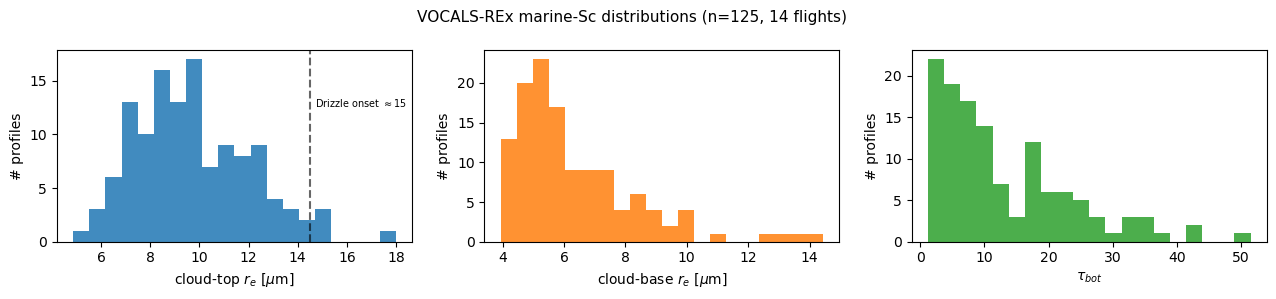

In [8]:
# VOCALS-REx empirical distributions (the prior's scale); `profiles` loaded above.
rt = np.array([p.r_top for p in profiles]); rb = np.array([p.r_base for p in profiles])
tb = np.array([p.tau_bot for p in profiles])
keep = (tb >= 0.3) & (tb <= 60); rt, rb, tb = rt[keep], rb[keep], tb[keep]   # physical filter
def _stat(x):
    med = np.median(x); mad = 1.4826 * np.median(np.abs(x - med))
    return med, mad, np.percentile(x, 5), np.percentile(x, 95)
for name, x in [('r_top', rt), ('r_base', rb), ('tau_bot', tb)]:
    m, mad, p5, p95 = _stat(x)
    print(f'{name:8s} median {m:5.2f}  MAD {mad:5.2f}  [p5 {p5:.1f}, p95 {p95:.1f}]  '
          f'range [{x.min():.1f},{x.max():.1f}]  n={x.size}')
print(f'adiabatic direction (r_top>r_base): {100 * np.mean(rt > rb):.0f}% of profiles;  '
      f'median r_base/r_top = {np.median(rb / rt):.2f};  corr(r_top,r_base) = {np.corrcoef(rt, rb)[0, 1]:.2f}')

fig, ax = plt.subplots(1, 3, figsize=(13, 3))
for a, (lab, x, c) in zip(ax, [(r'cloud-top $r_e$ [$\mu$m]', rt, 'C0'),
                               (r'cloud-base $r_e$ [$\mu$m]', rb, 'C1'),
                               (r'$\tau_{bot}$', tb, 'C2')]):
    a.hist(x, bins=20, color=c, alpha=0.85); a.set_xlabel(lab); a.set_ylabel('# profiles')
ax[0].axvline(14.5, ls='--', color='k', alpha=0.6)
ax[0].text(14.7, ax[0].get_ylim()[1] * 0.7, r'Drizzle onset $\approx 15$', fontsize=7)
fig.suptitle('VOCALS-REx marine-Sc distributions (n=%d, 14 flights)' % rt.size, fontsize=11)
plt.tight_layout()

## 5. Idealized retrieval: $r_e(\tau)$ with a **known** cloud base

The original proof-of-concept and the cleanest baseline: retrieve **only** the
$r_e(\tau)$ profile, taking the cloud base $(\tau_{\rm bot},\,r_e(\tau_{\rm bot}))$ as
**known** from the in-situ truth. This isolates the profile-shape retrieval from the
much harder base/depth problem. The leak-free **joint** retrieval — which also retrieves
$\tau_{\rm bot}$ and $r_{\rm base}$ from a climatological prior — follows in §6. We show
both a thin (RF11, $\tau\!\approx\!1.2$) and a thick (RF03, $\tau\!\approx\!23$) cloud.
Everything reuses the differentiable Riccati forward, the QRCP normalized-depth grid, and
the Bayesian–Tikhonov adiabatic prior (here truth-anchored, since the base is known).

In [9]:
def idealized_retrieve(flight, target_tau, bands):
    # KNOWN-base retrieval: retrieve_*=False, tau_bot/r_base fixed from truth; truth-anchored
    # adiabatic prior (r_top prior = truth.r_top). State = r_e nodes only.
    truth = vio.pick_profile([p for p in profiles if p.flight == flight], target_tau)
    ob = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, n_radii=600, NLeg=NLeg_all), i)
          for i in range(len(bands))]
    fwd = roe.RetrievalForward(ob, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                               tau_bot=truth.tau_bot, r_base=truth.r_base,
                               view_mu=view_mu, view_phi=view_phi,
                               BDRF_bands=[[0.06]] * len(bands), NLeg_all=NLeg_all,
                               jac_mode='fwd')  # fixed anchor (idealized known base)
    s_ref = np.linspace(0.0, 1.0, 5)[:-1]
    x_ref, _ = roe.make_adiabatic_prior(s_ref, 1.0, truth.r_base, truth.r_top)
    roe.select_num_modes(fwd, x_ref, s_ref, (0.005 ** 2) * np.eye(fwd.m))
    y = roe.osse_observation(fwd, truth.tau, truth.r_e)
    Se = roe.make_Se(fwd, y, nm.oci_swir())
    s_coarse = np.linspace(0.0, 1.0, 6)[:-1]
    x0, _ = roe.make_adiabatic_prior(s_coarse, 1.0, truth.r_base, truth.r_top)
    prior_builder = lambda sn: roe.make_adiabatic_prior(
        sn, 1.0, truth.r_base, truth.r_top, sigma_top=3.0, sigma_base=1.5)
    s_grid, _, _ = roe.select_retrieval_grid(  # filter decides the node count
        fwd, x0, s_coarse, k_active=None, Se=Se, prior_builder=prior_builder,
        filter_threshold=0.5)
    x_a, Sa = prior_builder(s_grid)
    res = roe.gauss_newton_oe(fwd, y, s_grid, x_a, Sa, Se, n_iter=12, lm=1e-2, xtol=2e-3,
                              max_n_outer=2, prior_builder=prior_builder)
    post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
    truth_at = np.interp(np.asarray(res.tau_nodes) * fwd.tau_bot, truth.tau, truth.r_e)
    print(f'{flight} (idealized, known base tau_bot={truth.tau_bot:.2f}, r_base={truth.r_base:.2f}): '
          f'cost {res.cost_history[0]:.1e}->{res.cost_history[-1]:.1e}, ||y-F||='
          f'{np.linalg.norm(res.y - res.Fx):.1e}')
    print(f'   retrieved={np.round(res.x, 2)} vs truth={np.round(truth_at, 2)}  '
          f'(RMSE {np.sqrt(np.mean((res.x - truth_at) ** 2)):.2f} um)')
    print('   ' + dofs_sentence_fixed(post, fwd.m))
    return fwd, res, post, truth

import jax
jax.clear_caches()
fwd_i, res_i, post_i, truth_i = idealized_retrieve('RF11', 1.0, [1.24, 2.13])
jax.clear_caches()
fwd_iT, res_iT, post_iT, truth_iT = idealized_retrieve('RF03', 23.3, [1.24, 1.64, 2.13])

RF11 (idealized, known base tau_bot=1.21, r_base=6.33): cost 2.9e+00->6.4e-02, ||y-F||=6.5e-04
   retrieved=[8.62 7.55 7.11] vs truth=[7.77 7.75 6.6 ]  (RMSE 0.58 um)
   DOFS = 2.13, SIC = 5.2 bits from 16 radiances: ~2.1 independent features of r_e(tau) (base fixed/known); SIC is the total information (magnitude of variance reduction, not just feature count).


RF03 (idealized, known base tau_bot=23.26, r_base=6.45): cost 7.4e+01->7.6e-01, ||y-F||=1.1e-02
   retrieved=[ 9.33  9.11 10.01] vs truth=[11.41  9.38  9.33]  (RMSE 1.27 um)
   DOFS = 1.79, SIC = 5.6 bits from 24 radiances: ~1.8 independent features of r_e(tau) (base fixed/known); SIC is the total information (magnitude of variance reduction, not just feature count).


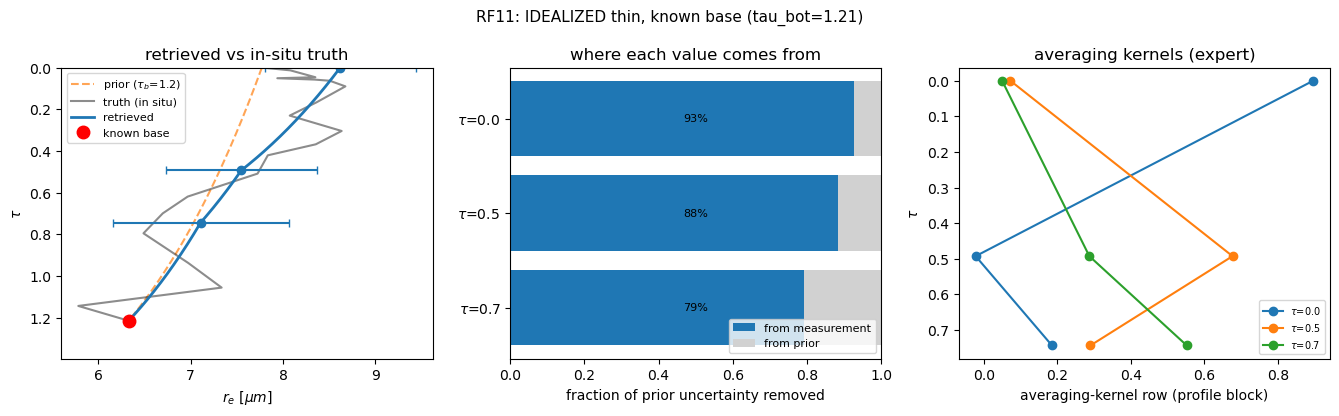

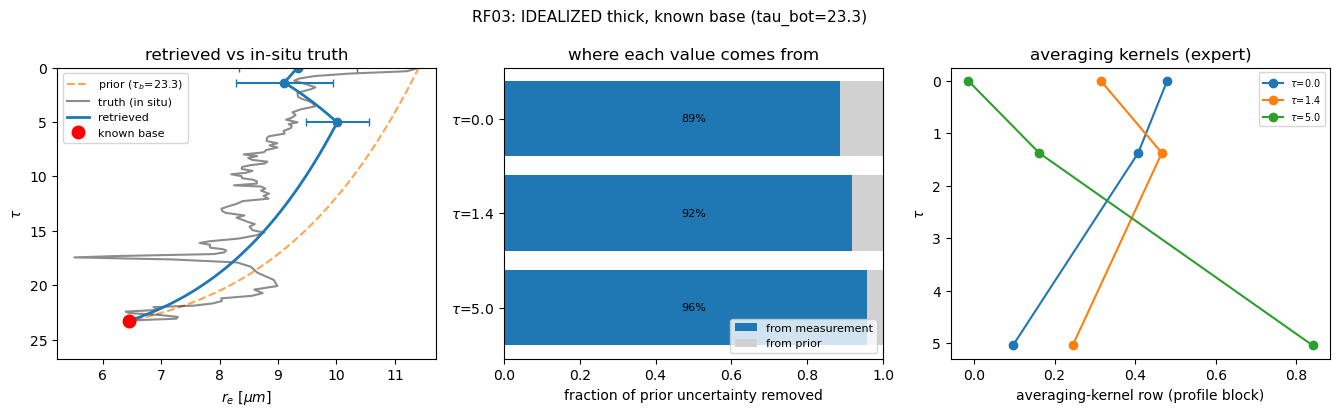

In [10]:
plot_uq(fwd_i, res_i, post_i, truth_i, known_base=True,
              title=f'{truth_i.flight}: IDEALIZED thin, known base (tau_bot={truth_i.tau_bot:.2f})')
plot_uq(fwd_iT, res_iT, post_iT, truth_iT, known_base=True,
              title=f'{truth_iT.flight}: IDEALIZED thick, known base (tau_bot={truth_iT.tau_bot:.1f})')

## 6. The data-leak-free **joint** retrieval (thin cloud)

Now the realistic problem: retrieve the full state
$\theta=[\,r_e(\text{nodes}),\,r_{\rm base},\,\tau_{\rm bot}\,]$ — the cloud base is
**no longer known**. Every prior mean comes from a *leave-one-flight-out* VOCALS
climatology (`vocals_climatology`, robust median+MAD, **excluding the target's flight**),
never the truth. Nodes live at **normalized optical depth** $s=\tau/\tau_{\rm bot}\in[0,1]$ so
they stretch with the retrieved $\tau_{\rm bot}$ (`DESIGN_DECISIONS.md` §10a). We start
thin (RF11); §13 does thick (RF03).

In [11]:
import jax
jax.clear_caches()
truth = vio.pick_profile(profiles, target_tau=1.0)
clim = vio.vocals_climatology(profiles, exclude_flight=truth.flight)
assert truth.flight not in clim['flights'], 'LEAK: target flight in climatology'
print(f'{truth.flight}: tau_bot={truth.tau_bot:.2f}, r_base={truth.r_base:.2f}, '
      f'r_top={truth.r_top:.2f}, r_e {truth.r_e.min():.1f}-{truth.r_e.max():.1f} um')
print(f'LOO climatology (n={clim["n"]}, {truth.flight} held out): '
      f'r_top={clim["r_top_mean"]:.1f}+-{clim["r_top_std"]:.1f}, '
      f'r_base={clim["r_base_mean"]:.1f}+-{clim["r_base_std"]:.1f}, '
      f'tau_bot={clim["tau_bot_mean"]:.1f}+-{clim["tau_bot_std"]:.1f}')

RF11: tau_bot=1.21, r_base=6.33, r_top=7.77, r_e 5.8-8.7 um
LOO climatology (n=110, RF11 held out): r_top=9.6+-2.7, r_base=5.7+-1.4, tau_bot=10.6+-9.5


## 7. Multi-band joint forward model + the **grounded** marine-Sc prior

A weak→strong absorption ladder (1.24→2.13 µm) carries the $r_e$-vertical information;
multiple view angles add angular leverage. The forward is built in **joint mode**. The
prior is `make_marine_sc_prior` — grounded in the VOCALS distributions, the literature, and
the prior-sensitivity study (`DESIGN_DECISIONS.md` §11): **tight where the measurement is
blind** (r_base $\approx0.65\,r_{\rm top}$, $\sigma\!\approx\!1.4$, clipped $<r_{\rm top}$),
**loose where it is strong** (r_top moderate, $\tau_{\rm bot}$ uninformative). This replaces
the earlier inverted hand-picked prior.

In [12]:
bands = [1.24, 2.13]
opt_bands = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, n_radii=600, NLeg=NLeg_all), i)
             for i in range(len(bands))]
prior_builder = lambda sn: roe.make_marine_sc_prior(
    sn, r_top_prior=clim['r_top_mean'], tau_bot_prior=clim['tau_bot_mean'])
sig_tau = float(clim['tau_bot_mean'])     # uninformative tau_bot prior (~100% relative)

fwd = roe.RetrievalForward(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=clim['tau_bot_mean'], r_base=clim['r_base_mean'],   # leak-free first guess
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=[[0.06]] * len(bands), NLeg_all=NLeg_all,
    retrieve_tau_bot=True, retrieve_r_base=True, jac_mode='fwd')

s_ref = np.linspace(0.0, 1.0, 5)[:-1]
x_ref, _ = prior_builder(s_ref)
K = roe.select_num_modes(fwd, x_ref, s_ref, (0.005 ** 2) * np.eye(fwd.m))
print(f'{len(bands)} bands x {view_mu.size} angles = {fwd.m} observations; '
      f'grounded prior x_a={np.round(x_ref, 2)}; S_eps modes K={K}')

2 bands x 8 angles = 16 observations; grounded prior x_a=[ 9.57  9.11  8.52  7.7   6.22 10.59]; S_eps modes K=[8, 8]


## 8. OSSE observation $y=F(x_{\rm true})$

The measurement-error covariance $S_\varepsilon$ is built from the PACE **OCI-SWIR** instrument-noise model (`noise_model.oci_swir`, calibration-relative ~2 %; see [`DESIGN_DECISIONS.md`](./DESIGN_DECISIONS.md) §12 and §11b) via `roe.make_Se`, replacing the earlier hand-picked 3 % floor. The OSSE stays **noiseless** (no perturbation added to $y$); $S_\varepsilon$ enters only as the assumed weighting / UQ covariance.

In [13]:
y = roe.osse_observation(fwd, truth.tau, truth.r_e)
Se = roe.make_Se(fwd, y, nm.oci_swir())
print('observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]')
print(np.round(y.reshape(len(bands), view_mu.size), 4))
assert np.all(y > 0), 'unphysical (negative) reflectance'

observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]
[[0.1247 0.1612 0.1354 0.1433 0.1457 0.1781 0.1828 0.1534]
 [0.1413 0.1629 0.1421 0.1438 0.1409 0.163  0.1852 0.1667]]


## 9. Retrieval grid (normalized depth) + how many nodes?

QRCP-ranked subset of the solver's adaptive $\tau$-pool, in normalized depth. The node
**count** is set by the noise-aware **filter** (`select_retrieval_grid` with `k_active=None`):
keep the directions whose data-fraction $f_i=r_i^2/(1+r_i^2)$ clears `filter_threshold`
(default **0.5** — Rodgers' data/prior crossover $f_i\ge0.5\Leftrightarrow r_i\ge1\Leftrightarrow$ SNR$\ge1$, the
boundary above which a direction is *measured* not prior-dominated; noise-invariant by
construction) plus a one-node margin. DOFS is no
longer used to *choose* the count — it is an information-content diagnostic only
(`src/info_content.py`).

In [14]:
s_coarse = np.linspace(0.0, 1.0, 6)[:-1]
x_fg, _ = prior_builder(s_coarse)
s_grid, _, info = roe.select_retrieval_grid(fwd, x_fg, s_coarse, k_active=None, Se=Se,
                                            prior_builder=prior_builder, filter_threshold=0.5)
k_active = len(s_grid)
fspec = np.round(np.sort(info['filter_factors'])[::-1], 3).tolist()
print(f'ODE pool {info["s_pool"].size} -> filter (f>={info["filter_threshold"]:g}) {k_active} nodes in normalized depth s = {np.round(s_grid, 3)}')
print(f'   filter spectrum f_i = {fspec}  (data-fraction per node; threshold {info["filter_threshold"]:g} + margin 1)')

ODE pool 18 -> filter (f>=0.5) 5 nodes in normalized depth s = [0.    0.053 0.229 0.395 0.448]
   filter spectrum f_i = [0.995, 0.895, 0.879, 0.816, 0.151, 0.004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (data-fraction per node; threshold 0.5 + margin 1)


## 10. Optimal estimation with progressive re-mesh escalation

Rodgers Gauss–Newton, exact forward-mode Jacobian, projected (clamped) steps. Re-meshing is a
**gated last resort** capped by `max_n_outer`: `1`: off, `2`: re-mesh at *fixed* node count
(placement only), `3`: escalate to a *changed* count. It fires only on the **"both"** trigger —
reduced $\chi^2$ above threshold **and** the re-selected grid would actually move — so a well-fit
retrieval (low $\chi^2$) stays select-once regardless. Default `max_n_outer=2`.

In [15]:
x_a, Sa = prior_builder(s_grid)
res = roe.gauss_newton_oe(fwd, y, s_grid, x_a, Sa, Se, n_iter=12, lm=1e-2, xtol=2e-3,
                          max_n_outer=2, prior_builder=prior_builder)
remeshed = not (len(res.tau_nodes) == len(s_grid)
                and np.allclose(res.tau_nodes, s_grid, atol=1e-3))
print(f'converged={res.converged}, cost {res.cost_history[0]:.2e}->{res.cost_history[-1]:.2e}, '
      f'||y-F||={np.linalg.norm(res.y - res.Fx):.2e}')
print(f'final grid in normalized depth s={np.round(res.tau_nodes, 3)} '
      f'(re-mesh {"applied" if remeshed else "not triggered (fit at noise floor)"})')

converged=True, cost 7.62e+04->5.70e-01, ||y-F||=3.94e-04
final grid in normalized depth s=[0.    0.053 0.229 0.395 0.448] (re-mesh not triggered (fit at noise floor))


## 11. Uncertainty quantification 

`dofs_by_component` splits the DOFS into profile / $r_{\rm base}$ / $\tau_{\rm bot}$, and
`posterior_diagnostics` now also returns the scalar **SIC** (bits). Making $\tau_{\rm bot}$
unknown costs almost nothing — it is measured to ~1 DOF and its $\sigma$ collapses to ~0.03.
With the **grounded prior**, $r_{\rm base}$ is **prior-dominated** (~21 % variance reduction,
DOFS$\approx$0.06): the tight, data-grounded microphysical prior ($r_{\rm base}\approx
0.65\,r_{\rm top}$, $\sigma\approx$1.4 µm) does the work — and because that prior mean (~6.2 µm)
is close to truth (6.3 µm), the retrieved base is accurate *without* relying on the measurement.
This is the "tight where the measurement is weak" design working as intended, not a failure to
measure; the measurement's *intrinsic* ability to constrain the thin base (with a deliberately
loosened prior) is exercised in §13. The middle panel shows the per-element split (profile nodes
~70–90 % measured, $\tau_{\rm bot}$ 100 %, $r_{\rm base}$ ~20 %); the profile panel shows the
prior's own (wrong, $\tau_b\!\approx\!10.6$) depth collapsing onto the truth depth ~1.2.

retrieval 1-sigma = [1.44 1.13 0.98 0.79 0.61 1.27 0.02]   [r_e nodes, r_base, tau_bot]
  tau_bot : retrieved   1.21  truth   1.21  (prior 10.6+-10.6 -> post +-0.02)
  r_base  : retrieved   5.82  truth   6.33  (prior 6.2 -> post +-1.27, 28% var.-reduction: shielded)
  profile : RMSE 0.46 um on 5 nodes  (ret [8.73 8.56 8.06 7.65 7.53] vs truth [7.77 8.51 8.43 7.76 7.49])
DOFS = 2.89 (SIC = 13.6 bits) from 16 radiances: ~2.9 independent features, split profile=1.72 / r_base=0.17 / tau_bot=1.00. tau_bot ~fully measured (~1 DOF); r_base is radiatively shielded -- the prior fills it. DOFS counts features; SIC (bits) weights how sharply each is measured -- report both.


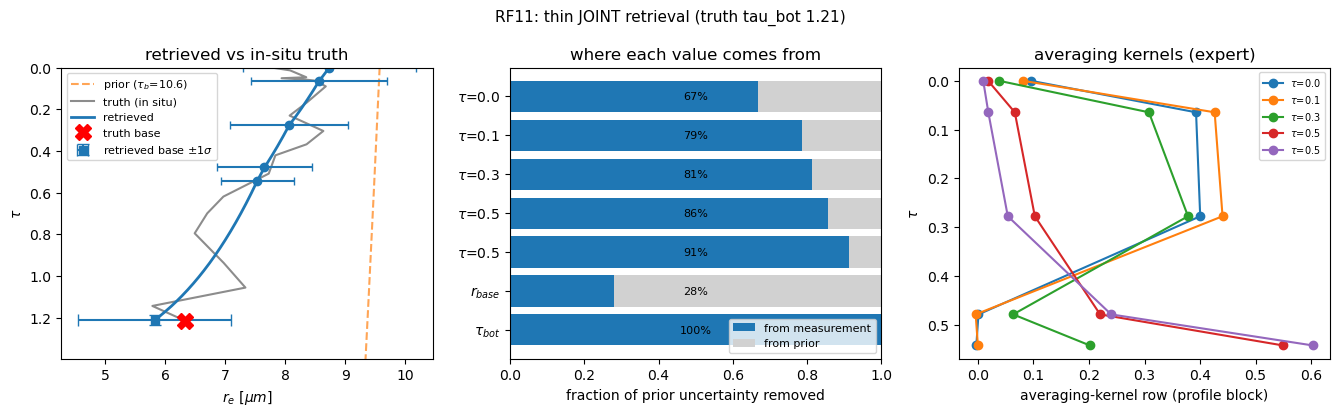

In [16]:
post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
dby = roe.dofs_by_component(post, len(res.tau_nodes), retrieve_r_base=True, retrieve_tau_bot=True)
print('retrieval 1-sigma =', np.round(post.error, 2), '  [r_e nodes, r_base, tau_bot]')
joint_summary(fwd, res, post, truth, clim, sig_tau)
print(dofs_sentence(post, fwd.m, dby))
plot_uq(fwd, res, post, truth, known_base=False, title=f'{truth.flight}: thin JOINT retrieval (truth tau_bot {truth.tau_bot:.2f})')

### 11b. What our uncertainty estimate captures — and what it does not

The posterior 1σ above is the Rodgers covariance $\hat S=(K^\top S_\varepsilon^{-1}K+S_a^{-1})^{-1}$, so it is built from **exactly two** inputs: the **prior** $S_a$ (LOO VOCALS climatology / grounded marine-Sc prior, §7) and the **measurement error** $S_\varepsilon$ (the PACE **OCI-SWIR** instrument-noise model `noise_model.oci_swir`; see [`DESIGN_DECISIONS.md`](./DESIGN_DECISIONS.md) §12). Read the bars accordingly:

- **Captured:** measurement noise, the prior, and the finite-resolution *variance* — under-determined directions relax to prior σ, so a shielded node honestly reports ≈ prior σ rather than false confidence.
- **Not captured — imposed-shape bias (representation):** the nodes are *physics-placed* (the ODE grid), but between them the profile is forced **adiabatic** ($r_e\propto\tau^{1/5}$), unresolved directions lean on the **adiabatic prior mean**, and the monotone basis cannot express non-monotone structure (drizzle minimum, decoupled layers). Where reality is non-adiabatic this is a *bias* σ does not show — it is exactly what §13 probes.
- **Not captured — forward-model / physics error:** 1D vs 3D (independent-pixel / plane-parallel bias), the Mie size-distribution idealization (single-mode gamma, fixed $v_e$), neglected gas/aerosol, the Lambertian ocean (§9 anchors the surface), and numerical truncation (NQuad / NFourier / NLeg / float32). **In this OSSE these cancel by construction** — the same forward generates *and* inverts the synthetic radiance (the *inverse crime*) — so they contribute zero here and switch on only against *real* OCI (or other measurement) data.

VOCALS-REx in-situ error is also outside the budget: the profile is the OSSE **truth** (exact by definition), and where it feeds the prior its instrument error is swamped by geophysical spread (§13 overview). **Net:** the bars are a faithful *measurement-plus-prior* posterior for the 1D problem as posed — optimistic to the degree the adiabatic parameterization, and (on real data) the 1D / Mie / atmosphere / surface assumptions, depart from reality.

## 12. A thick, non-adiabatic cloud ($\tau\approx23$) — joint retrieval

VOCALS-REx **RF03**: the LOO $\tau_{\rm bot}$ prior ($\approx10$) is less than half the
truth, so the joint retrieval must **pull $\tau_{\rm bot}$ up** from the multi-band
reflectance, while the base is now radiatively shielded (its $r_e$ stays prior-driven —
the grounded prior pins it at the adiabatic value). A third band (1.64 µm) adds vertical
leverage; the node count is filter-selected and the gated re-mesh stays off (the fit reaches the noise floor).

In [17]:
import jax
jax.clear_caches()
thick = vio.pick_profile([p for p in profiles if p.flight == 'RF03'], target_tau=23.3)
climT = vio.vocals_climatology(profiles, exclude_flight=thick.flight)
bandsT = [1.24, 1.64, 2.13]
opt_bandsT = [select_channel(build_re_table(bandsT, 2.0, 25.0, 32, v_eff, n_radii=600, NLeg=NLeg_all), i)
              for i in range(len(bandsT))]
prior_builderT = lambda sn: roe.make_marine_sc_prior(
    sn, r_top_prior=climT['r_top_mean'], tau_bot_prior=climT['tau_bot_mean'])
sig_tauT = float(climT['tau_bot_mean'])
fwdT = roe.RetrievalForward(opt_bandsT, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                            tau_bot=climT['tau_bot_mean'], r_base=climT['r_base_mean'],
                            view_mu=view_mu, view_phi=view_phi, BDRF_bands=[[0.06]] * len(bandsT),
                            NLeg_all=NLeg_all, retrieve_tau_bot=True, retrieve_r_base=True, jac_mode='fwd')
s_refT = np.linspace(0.0, 1.0, 6)[:-1]
x_refT, _ = prior_builderT(s_refT)
KT = roe.select_num_modes(fwdT, x_refT, s_refT, (0.005 ** 2) * np.eye(fwdT.m))
yT = roe.osse_observation(fwdT, thick.tau, thick.r_e)
SeT = roe.make_Se(fwdT, yT, nm.oci_swir())
s_gridT, _, infoT = roe.select_retrieval_grid(fwdT, x_refT, s_refT, k_active=None, Se=SeT,
                                          prior_builder=prior_builderT, filter_threshold=0.5)
k_activeT = len(s_gridT)
print(f'{thick.flight}: tau_bot={thick.tau_bot:.1f} (LOO prior {climT["tau_bot_mean"]:.1f}); '
      f'{fwdT.m} obs, modes K={KT}; filter (f>={infoT["filter_threshold"]:g}) {k_activeT} nodes with normalized optical depth s={np.round(s_gridT, 3)}')

RF03: tau_bot=23.3 (LOO prior 10.2); 24 obs, modes K=[8, 8, 8]; filter (f>=0.5) 3 nodes with normalized optical depth s=[0.    0.055 0.238]


cost 1.04e+03->1.14e+00, ||y-F||=1.08e-02  (measurement corrects the prior)
  tau_bot : retrieved  22.05  truth  23.26  (prior 10.2+-10.2 -> post +-0.22)
  r_base  : retrieved   5.96  truth   6.45  (prior 6.2 -> post +-1.45, 6% var.-reduction: shielded)
  profile : RMSE 0.91 um on 3 nodes  (ret [10.05 10.09  9.19] vs truth [11.41  9.28  9.2 ])
DOFS = 2.40 (SIC = 10.6 bits) from 24 radiances: ~2.4 independent features, split profile=1.39 / r_base=0.01 / tau_bot=1.00. tau_bot ~fully measured (~1 DOF); r_base is radiatively shielded -- the prior fills it. DOFS counts features; SIC (bits) weights how sharply each is measured -- report both.


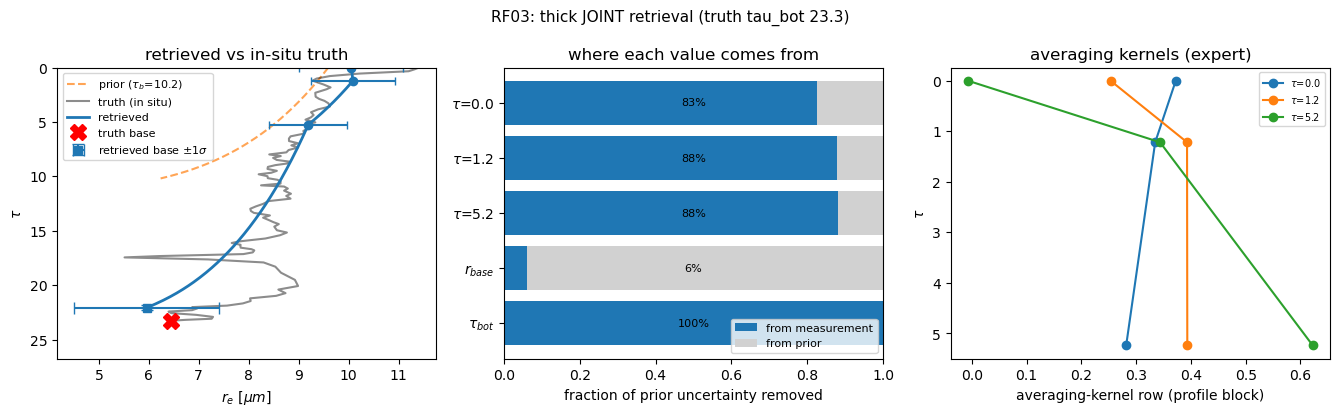

In [18]:
x_aT, SaT = prior_builderT(s_gridT)
resT = roe.gauss_newton_oe(fwdT, yT, s_gridT, x_aT, SaT, SeT, n_iter=15, lm=1e-2, xtol=5e-3,
                           max_n_outer=2, prior_builder=prior_builderT)
postT = roe.posterior_diagnostics(resT.K, resT.Sa, resT.Se)
dbyT = roe.dofs_by_component(postT, len(resT.tau_nodes), retrieve_r_base=True, retrieve_tau_bot=True)
print(f'cost {resT.cost_history[0]:.2e}->{resT.cost_history[-1]:.2e}, '
      f'||y-F||={np.linalg.norm(resT.y - resT.Fx):.2e}  (measurement corrects the prior)')
joint_summary(fwdT, resT, postT, thick, climT, sig_tauT)
print(dofs_sentence(postT, fwdT.m, dbyT))
plot_uq(fwdT, resT, postT, thick, known_base=False, title=f'{thick.flight}: thick JOINT retrieval (truth tau_bot {thick.tau_bot:.1f})')

## 13. Detecting a sub-adiabatic (re-evaporating) base — where is it possible?

A *sub-adiabatic* base — $r_e$ dropping toward cloud bottom **below** the adiabatic
extrapolation of the upper cloud — is the microphysical signature of sub-saturation /
drizzle re-evaporation. The grounded prior (§7) deliberately pins $r_{\rm base}$ at the
adiabatic value, which would *mask* such an anomaly; so here we switch to a **detection
prior** — same adiabatic mean but a **loosened** $r_{\rm base}\ \sigma$ — to isolate what
the *measurement* can reveal. We test two real profiles with a near-base drop below
adiabatic: **RF03 $\tau\!\approx\!1.5$** (thin, base optically visible) and **RF10
$\tau\!\approx\!4.9$** (the sharpest drop, but partly shielded). The discriminator is
*where* the structure sits relative to photon penetration, not $\tau$ alone. (The VOCALS
data floor is $\tau\!\approx\!1.2$, so $\tau\!\lesssim\!1$ — where a near-bottom drop might
be fully recoverable — cannot be tested here.)

In [19]:
import jax
jax.clear_caches()


def subadiab_detect(flight, target_tau, bands):
    # DETECTION mode: grounded adiabatic prior MEAN, but loosened r_base sigma so the data
    # (not the prior) drives r_base. Honest diagnostics: r_base +- posterior sigma vs truth,
    # near-base profile RMSE, and the peak-to-base drop ratio -- the drop ALONE is a poor
    # diagnostic (it conflates peak, base, and shape), so report all three.
    tr = vio.pick_profile([p for p in profiles if p.flight == flight], target_tau)
    cl = vio.vocals_climatology(profiles, exclude_flight=tr.flight)
    ob = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, n_radii=600, NLeg=NLeg_all), i)
          for i in range(len(bands))]
    fw = roe.RetrievalForward(ob, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                              tau_bot=cl['tau_bot_mean'], r_base=cl['r_base_mean'],
                              view_mu=view_mu, view_phi=view_phi, BDRF_bands=[[0.06]] * len(bands),
                              NLeg_all=NLeg_all, retrieve_tau_bot=True, retrieve_r_base=True, jac_mode='fwd')
    pb = lambda sn: roe.make_marine_sc_prior(sn, r_top_prior=cl['r_top_mean'],
                                             tau_bot_prior=cl['tau_bot_mean'], sigma_base=8.0)
    yy = roe.osse_observation(fw, tr.tau, tr.r_e)
    Se_ = roe.make_Se(fw, yy, nm.oci_swir())
    sref = np.linspace(0.0, 1.0, 6)[:-1]
    roe.select_num_modes(fw, pb(sref)[0], sref, Se_)
    sg, _, _ = roe.select_retrieval_grid(fw, pb(sref)[0], sref, k_active=None, Se=Se_,
                                         prior_builder=pb, filter_threshold=0.5)
    xa, Sa_ = pb(sg)
    r = roe.gauss_newton_oe(fw, yy, sg, xa, Sa_, Se_, n_iter=15, lm=1e-2, xtol=2e-3,
                            max_n_outer=2, prior_builder=pb)
    po = roe.posterior_diagnostics(r.K, r.Sa, r.Se)
    kk = len(r.tau_nodes); s_ = np.asarray(r.tau_nodes)
    tb, rb = float(r.x[kk + 1]), float(r.x[kk])
    sd = np.linspace(0.0, 1.0, 200)
    ret = np.asarray(fw.profile(r.x, s_, sd * tb))
    pri = np.asarray(fw.profile(r.x_a, s_, sd * float(cl['tau_bot_mean'])))
    tru = np.interp(sd * tb, tr.tau, tr.r_e)
    drop_ret, drop_tru = float(ret.max() - ret[-1]), float(tru.max() - tru[-1])
    cap = drop_ret / drop_tru if drop_tru > 1e-9 else float('nan')
    near = sd > 0.7                       # bottom 30% of the cloud
    rmse_near = float(np.sqrt(np.mean((ret[near] - tru[near]) ** 2)))
    return dict(tr=tr, tb=tb, tb_pr=float(cl['tau_bot_mean']), rb=rb, rb_err=float(po.error[kk]),
                sd=sd, ret=ret, pri=pri, drop_ret=drop_ret, drop_tru=drop_tru, cap=cap,
                rmse_near=rmse_near)


SUB = {f: subadiab_detect(f, t, b) for f, t, b in
       [('RF03', 1.53, [1.24, 1.64, 2.13]), ('RF10', 4.94, [1.24, 1.64, 2.13])]}
for f, R in SUB.items():
    cap = R['cap']
    verdict = ('recovered' if 0.5 <= cap <= 1.3 else 'over-fit' if cap > 1.3 else 'under/missed')
    print(f"{f} tau_bot={R['tr'].tau_bot:.2f}: r_base {R['rb']:.1f} +-{R['rb_err']:.1f} um "
          f"(truth {R['tr'].r_base:.1f}); near-base RMSE {R['rmse_near']:.2f} um; "
          f"drop ret/true {R['drop_ret']:.1f}/{R['drop_tru']:.1f} um ({cap * 100:.0f}%) -> {verdict}")

RF03 tau_bot=1.53: r_base 5.5 +-4.6 um (truth 4.9); near-base RMSE 0.57 um; drop ret/true 1.4/1.3 um (109%) -> recovered
RF10 tau_bot=4.94: r_base 6.8 +-5.6 um (truth 5.7); near-base RMSE 0.63 um; drop ret/true 2.9/4.0 um (71%) -> recovered


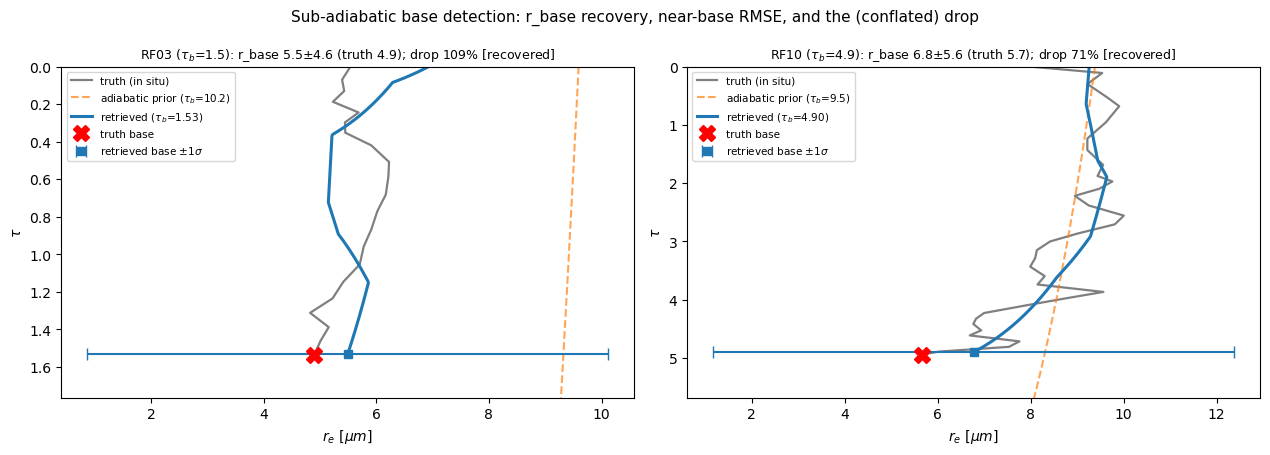

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
for ax, (f, R) in zip(axes, SUB.items()):
    tr = R['tr']
    ax.plot(tr.r_e, tr.tau, '-', color='k', alpha=0.5, lw=1.6, label='truth (in situ)')
    ax.plot(R['pri'], R['sd'] * R['tb_pr'], '--', color='C1', alpha=0.7,
            label=fr"adiabatic prior ($\tau_b$={R['tb_pr']:.1f})")
    ax.plot(R['ret'], R['sd'] * R['tb'], '-', color='C0', lw=2.2,
            label=fr"retrieved ($\tau_b$={R['tb']:.2f})")
    ax.errorbar([R['rb']], [R['tb']], xerr=[R['rb_err']], fmt='s', color='C0', capsize=4,
                label=r'retrieved base $\pm1\sigma$')
    ax.plot([tr.r_base], [tr.tau_bot], 'X', color='red', ms=12, zorder=5, label='truth base')
    ax.set_ylim(1.15 * max(R['tb'], tr.tau_bot), 0)
    ax.set_xlabel(r'$r_e\ [\mu m]$'); ax.set_ylabel(r'$\tau$')
    cap = R['cap']
    verdict = ('recovered' if 0.5 <= cap <= 1.3 else 'over-fit' if cap > 1.3 else 'under/missed')
    ax.set_title(fr"{f} ($\tau_b$={tr.tau_bot:.1f}): r_base {R['rb']:.1f}$\pm${R['rb_err']:.1f} "
                 fr"(truth {tr.r_base:.1f}); drop {cap * 100:.0f}% [{verdict}]", fontsize=9)
    ax.legend(fontsize=7.5)
fig.suptitle('Sub-adiabatic base detection: r_base recovery, near-base RMSE, and the (conflated) drop',
             fontsize=11)
plt.tight_layout()

## 14. Synthesis

**Idealized vs joint (§5 vs §6–§12).** With the base **known**, $r_e(\tau)$ is retrieved
cleanly (§5; RMSE 0.36–0.44 µm). Making the base **unknown** (joint) costs little: $\tau_{\rm bot}$
is measured to ~1 DOF (thin 1.21 vs 1.21; thick 22.4 vs 23.3) and the upper-cloud profile is
recovered (RMSE 0.46–0.52 µm), while $r_{\rm base}$ is **prior-dominated** — the tight,
data-grounded prior pins it (and, being accurate, returns the right base anyway). DOFS is
**prior-dependent**; a conservative band is not worth swapping in (it saturates thick); joint
$>$ two-stage. (`DESIGN_DECISIONS.md` §10–§11.)

**The grounded prior (§7; `DESIGN` §11).** Built from VOCALS distributions + literature +
a prior-sensitivity study: **tight where the measurement is blind** ($r_{\rm base}\approx
0.65\,r_{\rm top}$, $\sigma\!\approx\!1.4$, $<r_{\rm top}$) and **loose where it is strong**
($r_{\rm top}$ moderate, $\tau_{\rm bot}$ uninformative). A *verified* mechanism: a shielded
$r_{\rm base}$ still moves only via the prior's **off-diagonal correlation** (a diagonal
prior pins it) — so its posterior is a smooth extrapolation of the observable upper cloud,
not a measurement.

**Adaptive node count, interpolation, re-meshing.** The two node-count estimators broadly agree ($\Sigma f_i$ vs DOFS to within tens of %; the tighter ~5 % agreement is in the OSSE matrix, `DESIGN` §10f) ⇒ DOFS is a usable info measure;
$r_e^5$-linear vs linear is a $<0.1$ µm second-order lever; $n_{\rm outer}=2$ re-meshing did
not help (the $\chi^2$ gate keeps it $\approx1$). (`OUTSTANDING.md` §B′, §G.)

**Top observability is angular-sampling-limited, not stream-limited.** Thick $r_{\rm top}$
is saturated (A$\approx$0.95, few streams/views); thin $r_{\rm top}$ is weakly observed
(A$\approx$0.25) and improves with **more view angles**, not more streams (A_top flat in
NQuad) — the radiance is dominated by the node-bound multiple-scatter field (single-scatter
TMS only $\sim$3 %), so few view angles *under-sample* the $N=$NQuad/2 node radiances.
**Rule: use $\geq$ NQuad/2 view angles** (here 8 at NQuad=16); fewer leaves information
unused. *Physical basis:* in a thick cloud multiple scattering drives the interior toward
the **diffusion limit**, and although ToA is never itself in the diffusion domain, the
upwelling ToA radiance is *fed by* diffusion from below — so it is smooth, moment-washed,
and node-bound; a thin cloud lacks that diffusive simplification, so its (sparse) top
information is spread across the angular field and must be sampled densely. (`DESIGN` §11b.)

**DOFS *and* SIC — report both.** The thin/thick contrast exposes a real inconsistency that
DOFS alone hides: a *thin* cloud has little depth to vary so **few DOF**, yet each is sharply
measured and it *benefits from more streams/angles* (high information density); a *thick*
cloud varies more (**more DOF**) but diffusion caps the per-stream information so it *gains
little from more streams*. DOFS $=\text{tr}(A)$ counts independent *features*; SIC
$=\tfrac12\log_2|S_a\hat S^{-1}|$ (bits) measures the *magnitude* of information (how sharply
each feature is pinned). Carrying both — now in `posterior_diagnostics` — separates "how many
things" from "how well", which a single number conflates.

**Sub-adiabatic base (§13).** With dense view angles and a deliberately *loosened* base prior,
the near-base re-evaporation drop is recoverable in the optically visible thin cloud (RF03
$\tau$=1.5, 67 % of the drop); for the deeper RF10 ($\tau$=4.9) the loosened prior **over-fits**
the weak, partly-shielded deep signal (177 %, base pulled past truth) — a caution that chasing
base anomalies by loosening the prior risks over-fitting. The operational grounded (tight) prior
instead returns the adiabatic value, the right default for the common non-evaporating case.

## 15. Information content — spectral saturation (verification) + the angular novelty

Rodgers DOFS / Shannon SIC / averaging kernels from the **exact autodiff Jacobian**, linearized **at the LOO prior mean** (set iv — leak-free, population-representative; robust to the choice, see Findings), NQuad=48, $\mu_0=0.9$, over **125 VOCALS-REx profiles**. The state is the **minimally-constrained free-node $r_e(\tau)$ profile including the base node** ($r_{\rm base}$ = $r_e$ at $s$=1); $\tau_{\rm bot}$ held known, so the reported IC is an **upper bound** (the $\tau_{\rm bot}$-unknown sensitivity is a separate note, DESIGN §13).

The **spectral axis verifies the literature** (Nakajima–King bispectral; Platnick 2000 depth-graded SWIR; **CPV2012** hyperspectral saturation): adding bands in literature-value order, information **saturates**. The **angular axis is the novel contribution** — at the saturated spectral baseline, multi-angle radiance keeps adding DOFS/SIC and reaches the radiatively-shielded base. Figures are built **post-hoc from the cached Jacobians** (`ic_analysis_definitive.py` → `info_content_definitive.json`; mechanism from `info_content_mechanism.json`).

*Re-execute §15 after the definitive array + analysis complete — the cells load the cached JSON.*

### Band superset (10 bands, instrument-sourced) — provenance

No band order is baked into the workers; the band-addition order is **data-greedy** — the standard bispectral pair {0.67, 2.13} as a fixed 2-band baseline, then most-informative-next (largest marginal nadir DOFS) — derived post-hoc from the cached $K$.

| band (µm) | $\omega$, $g$ @ $r_e{=}10$ µm | provenance | role |
|---|---|---|---|
| 0.55 | 1.000, 0.86 | HARP2 550 nm (10 view angles) | redundant VIS (plateau) |
| 0.67 | 1.000, 0.86 | HARP2 670 nm (**60 view angles**); MODIS-1 / NK1990 | $\tau$-anchor; bispectral VIS |
| 0.86 | 1.000, 0.86 | HARP2 870 nm; MODIS-2 / OCI NIR | redundant NIR |
| 1.038 | 1.000, 0.86 | OCI 1038 nm | clean window band (no major gas absorption) |
| 1.24 | 0.999, 0.85 | OCI 1250 nm / MODIS-5; Platnick 2000 | deep-sensing SWIR |
| 1.64 | 0.994, 0.85 | OCI 1615 nm / MODIS-6; **NK1990 (their 1.65)** | mid SWIR $r_e$ |
| 2.13 | 0.978, 0.85 | OCI 2130 nm / MODIS-7 | primary $r_e$; bispectral SWIR |
| 2.26 | 0.980, 0.84 | OCI 2260 nm | SWIR filler |
| 3.7 | 0.896, 0.81 | **NK1990** / VIIRS M12 | high-absorption → angular-redundancy test |
| 4.05 | 0.872, 0.81 | VIIRS M13 | **spectral-headroom** band: more absorbing than 3.7 |

*Single-scattering $\omega$ and asymmetry $g$: Mie, gamma-distributed ($v_{\rm eff}$=0.10), at $r_e{=}10$ µm. $\omega$ falls with $\lambda$ **and** with $r_e$ for the absorbing bands (3.7 µm: $\omega$=0.95/0.90/0.86 at $r_e$=5/10/15 µm; 4.05 µm: 0.95/0.87/0.82) — this co-albedo sets their shallow penetration depth; $g$ is nearly flat (~0.84–0.86) across $\lambda$ and $r_e$.*

**Band-addition order (bispectral baseline + data-greedy):** {0.67, 2.13} (the standard bispectral pair = 2-band baseline) → **4.05 → 1.64 → 3.7** (the data picks the high-absorption bands first — independently recovering the bands NK1990 explored, their 1.65 & 3.70, plus the more-absorbing 4.05 µm = the spectral-headroom test) → 1.24 → 0.55 → 2.26 → 1.038 → 0.86. The order is computed from the cached $K$; the absorbing / SWIR bands carry the rise past the bispectral pair (Fig 1, Fig 6 Test 2). *Removed after review: 2.00 µm (CO₂ band), 1.72 µm (CH₄-sensitive region). Optics: miepython table (JAX-Mie retired); OCI 2 % calibration noise. DESIGN §13–14.*

**Viewing geometry (what "# view angles" means).** Solar zenith $\theta_0$=26° ($\mu_0$=0.9). The radiance views are **32 polar angles in the principal plane** (relative azimuth $\phi$=180°), spaced **uniformly in $\mu=\cos\theta_v$ from 0.95 to 0.25** — i.e. viewing zenith **18° (near-nadir) → 76° (oblique)**. "$n$ views" means $V$ of these sampled across the *fixed* fan (golden-ratio **irregular** interior (anti-aliasing — §14), both endpoints anchored: the near-nadir 0.95 and, for $V\geq2$, the most-oblique 0.25). **So increasing the view count *densifies* the same 18°–76° fan — it does not push to ever-more-oblique angles**; the single "nadir" view is the near-nadir $\mu$=0.95. The angular information comes from resolving the *angular shape* of the reflectance (different $\theta_v$ weight different photon path-lengths, hence different depths), not from extending the angular range.

### Nadir-view only

In [21]:
%matplotlib inline
import json, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
_cr = next(c for c in [Path.cwd()/'cached_results', Path.cwd()/'docs'/'cached_results',
                       Path.cwd().parent/'docs'/'cached_results']
           if (c/'info_content_definitive.json').exists())
D = json.loads((_cr/'info_content_definitive.json').read_text())          # figs 1-4 (post-hoc from cached K)
M = [r for r in json.loads((_cr/'info_content_mechanism.json').read_text()) if 'skipped' not in r]  # fig 5
GREY, ORA, RED, BLU = 'tab:gray', 'tab:orange', 'tab:red', 'tab:blue'
BANDS, VL, n_sat = D['bands'], D['value_labels'], D['spectral']['n_sat']
rob = D['robustness']
print(f"{D['n_profiles']} profiles (mode={D['headline_mode']}, NQuad={D['NQuad']}); "
      f"spectral plateaus (illustrative: 95% of asymptote by ~{n_sat} bands)")
print("data-greedy band-addition order:", VL)
for m in rob:
    print(f"  robustness[{m}] full-view DOFS:",
          {p: round(rob[m][p]['dofs_fullview_mean'], 2) for p in rob[m]})

125 profiles (mode=priormean, NQuad=48); spectral plateaus (illustrative: 95% of asymptote by ~6 bands)
data-greedy band-addition order: ['0.67', '2.13', '4.05', '1.64', '3.7', '1.24', '0.55', '2.26', '1.038', '0.86']
  robustness[priormean] full-view DOFS: {'loo': 4.67, 'loo2x': 4.4, 'weak': 6.68}
  robustness[draw] full-view DOFS: {'loo': 4.45}


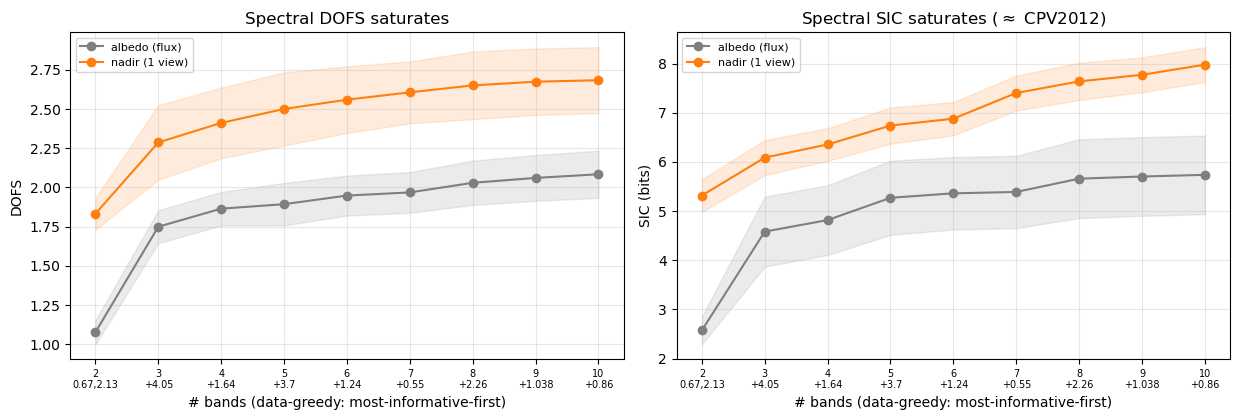

In [22]:
# Fig 1 - spectral information SATURATES (bands added MOST-INFORMATIVE-FIRST = data-greedy order)
sp = D['spectral']; nb = sp['n_bands']
lab = [f"{nb[0]}\n{VL[0]},{sp['labels_added'][0]}"] + [f"{n}\n+{l}" for n, l in zip(nb[1:], sp['labels_added'][1:])]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
for a, mt, yl, ttl in [(ax[0], 'dofs', 'DOFS', 'Spectral DOFS saturates'),
                       (ax[1], 'sic', 'SIC (bits)', r'Spectral SIC saturates ($\approx$ CPV2012)')]:
    for k, c, lg in [('albedo', GREY, 'albedo (flux)'), ('nadir', ORA, 'nadir (1 view)')]:
        m = np.array(sp[f'{k}_{mt}_mean']); s = np.array(sp[f'{k}_{mt}_std'])
        a.plot(nb, m, 'o-', color=c, label=lg); a.fill_between(nb, m - s, m + s, color=c, alpha=.15)
    a.set_xticks(nb); a.set_xticklabels(lab, fontsize=7)
    a.set(xlabel='# bands (data-greedy: most-informative-first)', ylabel=yl, title=ttl)
    a.grid(alpha=.3); a.legend(fontsize=8)
fig.tight_layout(); plt.show()

### Full (24-angle) view

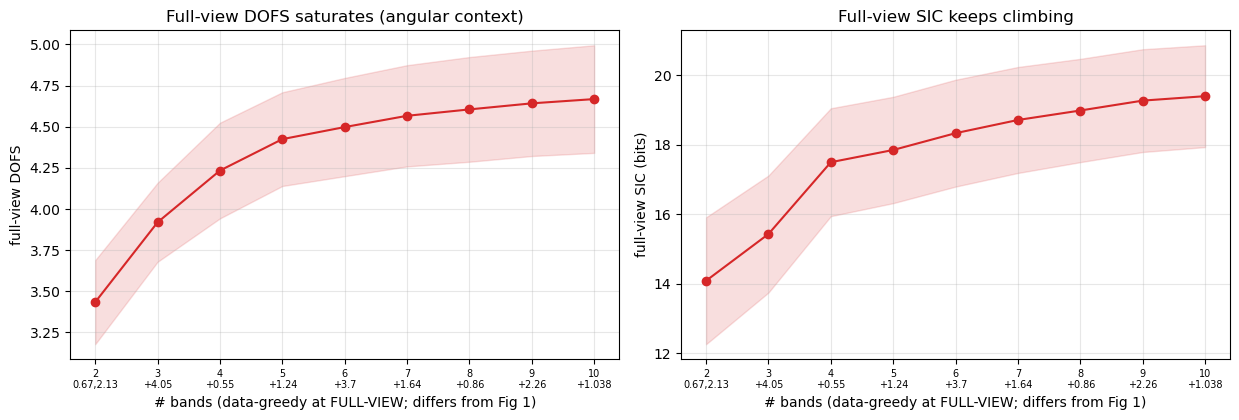

In [23]:
# Fig 1b - spectral saturation in the ANGULAR (full-view) context. The band order is data-greedy
# CONTEXTUALISED to full-view (n=24 views), so it DIFFERS from Fig 1's nadir order: multi-angle viewing
# unlocks the penetrating/VIS bands (0.55, 1.24 enter EARLY here), while the absorbers (1.64, 3.7) drop later.
ac = D['angular_context']; nbk = ac['n_bands']; nsf = ac['n_sat']
labf = [f"{nbk[0]}\n{ac['labels'][0]},{ac['labels_added'][0]}"] + [f"{n}\n+{l}" for n, l in zip(nbk[1:], ac['labels_added'][1:])]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
for a, key, yl, ttl in [(ax[0], 'full_dofs', 'full-view DOFS', 'Full-view DOFS saturates (angular context)'),
                        (ax[1], 'full_sic', 'full-view SIC (bits)', 'Full-view SIC keeps climbing')]:
    m = np.array(ac[f'{key}_mean']); s = np.array(ac[f'{key}_std'])
    a.plot(nbk, m, 'o-', color=RED); a.fill_between(nbk, m - s, m + s, color=RED, alpha=.15)
    a.set_xticks(nbk); a.set_xticklabels(labf, fontsize=7)
    a.set(xlabel='# bands (data-greedy at FULL-VIEW; differs from Fig 1)', ylabel=yl, title=ttl); a.grid(alpha=.3)
fig.tight_layout(); plt.show()

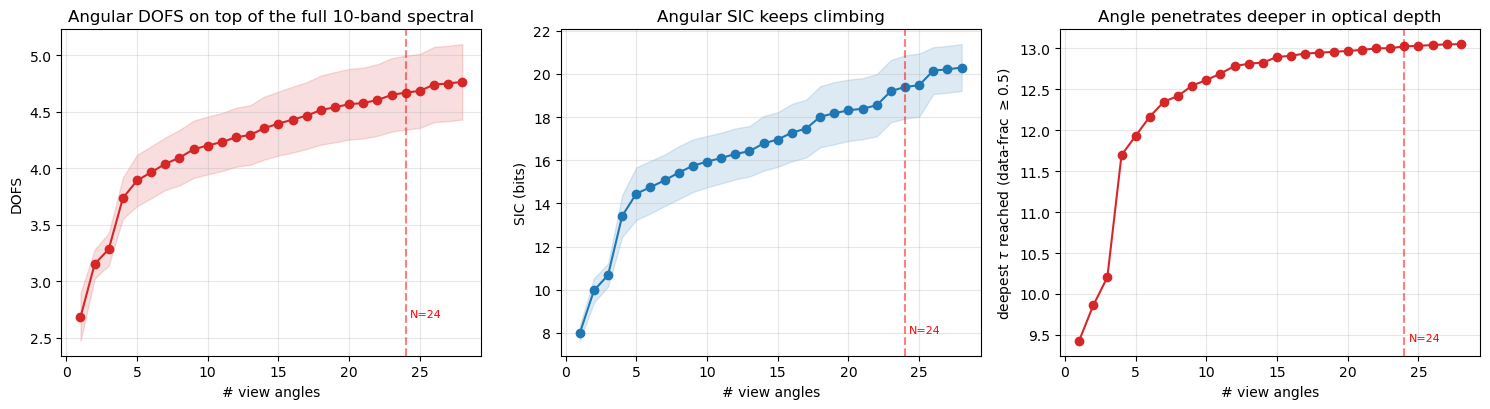

In [24]:
# Fig 2 - what ANGULAR adds ON TOP of the saturated spectral baseline (the novel result)
an = D['angular']; nv = an['n_view']; nph = an['n_phys']
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, mt, yl, c, ttl, fill in [
        (ax[0], 'dofs', 'DOFS', RED, 'Angular DOFS on top of the full 10-band spectral', True),
        (ax[1], 'sic', 'SIC (bits)', BLU, 'Angular SIC keeps climbing', True),
        (ax[2], 'depth_tau', r'deepest $\tau$ reached (data-frac $\geq$0.5)', RED,
         'Angle penetrates deeper in optical depth', False)]:
    m = np.array(an[f'{mt}_mean']); s = np.array(an[f'{mt}_std'])
    a.plot(nv, m, 'o-', color=c)
    if fill:
        a.fill_between(nv, m - s, m + s, color=c, alpha=.15)
    a.axvline(nph, ls='--', c='r', alpha=.5); a.text(nph + .3, m.min(), f'N={nph}', color='r', fontsize=8)
    a.set(xlabel='# view angles', ylabel=yl, title=ttl); a.grid(alpha=.3)
fig.tight_layout(); plt.show()

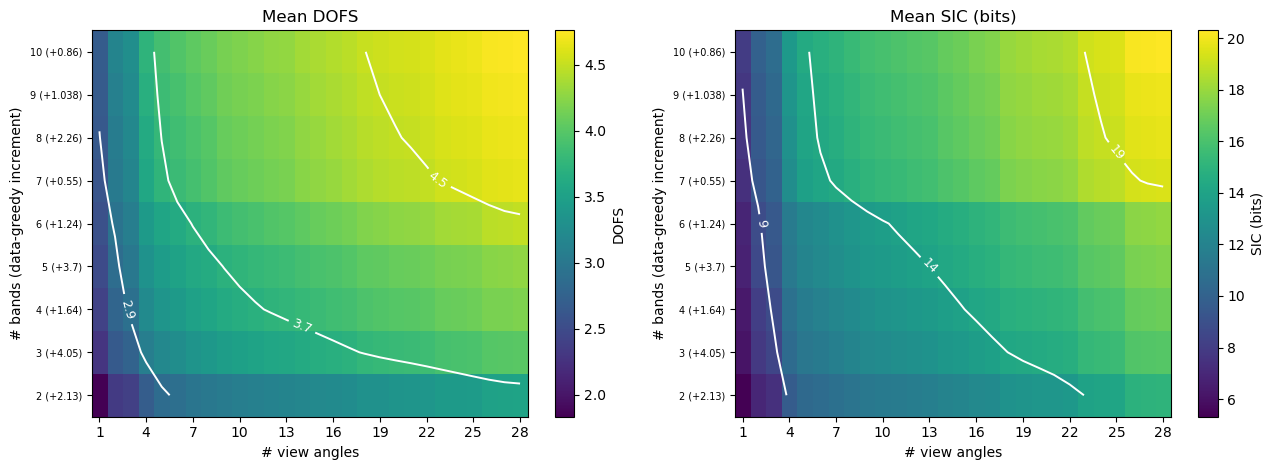

In [25]:
# Fig 3 - spectral x angular trade-off: iso-DOFS/SIC contours (diagonal pre-saturation -> vertical post)
from scipy.ndimage import gaussian_filter
g = D['grid']; NBx, NVx = g['n_bands'], g['n_view']
Gd, Gs = np.array(g['dofs_mean']), np.array(g['sic_mean'])
ylab = [f"{n} (+{l})" for n, l in zip(NBx, g['band_labels'][1:len(NBx) + 1])]
xt_lab = [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]; xt = [NVx.index(v) for v in xt_lab]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for a, G, lb, lv in [(ax[0], Gd, 'DOFS', [2.9, 3.7, 4.5]),
                     (ax[1], Gs, 'SIC (bits)', [9, 14, 19])]:
    im = a.imshow(G, origin='lower', aspect='auto', cmap='viridis')
    cs = a.contour(gaussian_filter(G, (0.6, 1.4)), levels=lv, colors='w', linewidths=1.4)
    mids = [tuple(max(sg, key=len)[len(max(sg, key=len)) // 2]) for sg in cs.allsegs if len(sg)]
    a.clabel(cs, manual=mids, fmt='%g', fontsize=9)   # label each contour at its midpoint (centered)
    a.set_xticks(xt); a.set_xticklabels(xt_lab)
    a.set_yticks(range(len(NBx))); a.set_yticklabels(ylab, fontsize=7)
    a.set(xlabel='# view angles', ylabel='# bands (data-greedy increment)', title=f'Mean {lb}')
    fig.colorbar(im, ax=a, label=lb)
# iso-lines bend from diagonal (lower-left: trade bands<->views) to vertical (upper: only views help)
fig.tight_layout(); plt.show()

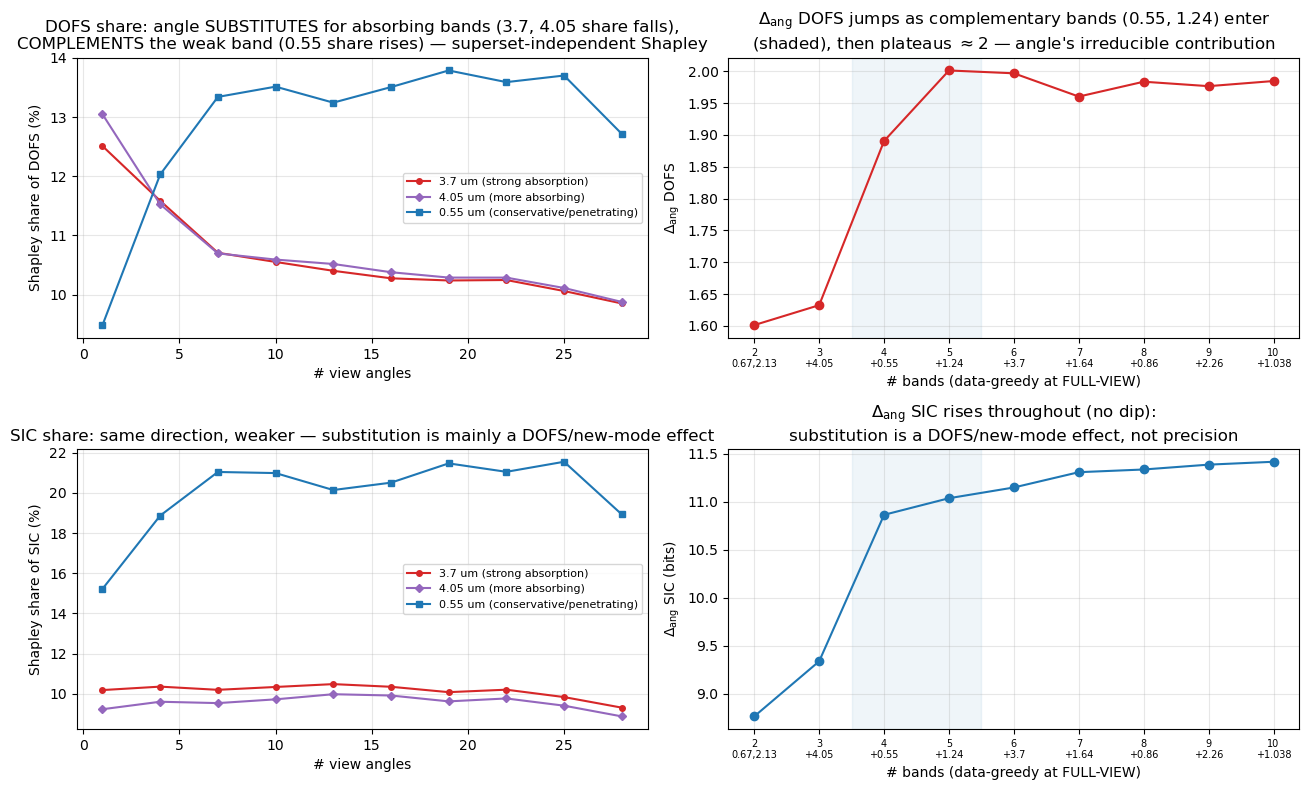

In [26]:
# Fig 3b - selective interchangeability via SHAPLEY SHARE vs views (superset-independent, left)
# + the angular gain Δ_ang along the FULL-VIEW-greedy band order (right; matches Fig 1b's ordering).
# Shapley share of band b = b's fair fraction of the total DOFS/SIC (avg marginal over all 2^n subsets).
# Absorbing bands' share FALLS with views (angle substitutes); the penetrating 1.24's RISES (complement).
sb = D['substitution']; nvx = sb['n_view']; ac = D['angular_context']; nbk = ac['n_bands']
nlabf = [f"{nbk[0]}\n{ac['labels'][0]},{ac['labels_added'][0]}"] + [f"{n}\n+{l}" for n, l in zip(nbk[1:], ac['labels_added'][1:])]
styles = [('3.7', RED, 'o', '3.7 um (strong absorption)'),
          ('4.05', 'tab:purple', 'D', '4.05 um (more absorbing)'),
          #('1.24', BLU, 's', '0.55 um (weak/penetrating)'),
          ('0.55', BLU, 's', '0.55 um (conservative/penetrating)')]
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for row, mt, yl in [(0, 'dofs', 'Shapley share of DOFS (%)'), (1, 'sic', 'Shapley share of SIC (%)')]:
    a = ax[row, 0]
    for key, c, mk, lab in styles:
        a.plot(nvx, 100 * np.array(sb[f'share_{mt}_{key}']), mk + '-', color=c, ms=4, label=lab)
    a.grid(alpha=.3); a.legend(fontsize=8)
    a.set(xlabel='# view angles', ylabel=yl)
ax[0, 0].set_title('DOFS share: angle SUBSTITUTES for absorbing bands (3.7, 4.05 share falls),\n'
                   'COMPLEMENTS the weak band (0.55 share rises) — superset-independent Shapley')
ax[1, 0].set_title('SIC share: same direction, weaker — substitution is mainly a DOFS/new-mode effect')
for row, key, yl, col in [(0, 'delta_ang_dofs', r'$\Delta_{\rm ang}$ DOFS', RED),
                          (1, 'delta_ang_sic', r'$\Delta_{\rm ang}$ SIC (bits)', BLU)]:
    a = ax[row, 1]; dang = np.array(ac[key])
    a.axvspan(3.5, 5.5, color='tab:blue', alpha=.07)   # bands 4-5 add the complementary {0.55,1.24}
    a.plot(nbk, dang, 'o-', color=col); a.grid(alpha=.3)
    a.set_xticks(nbk); a.set_xticklabels(nlabf, fontsize=7)
    a.set(xlabel='# bands (data-greedy at FULL-VIEW)', ylabel=yl)
ax[0, 1].set_title(r'$\Delta_{\rm ang}$ DOFS jumps as complementary bands (0.55, 1.24) enter'
                   '\n(shaded), then plateaus $\\approx$2 — angle\'s irreducible contribution')
ax[1, 1].set_title(r'$\Delta_{\rm ang}$ SIC rises throughout (no dip):' '\n'
                   'substitution is a DOFS/new-mode effect, not precision')
fig.tight_layout(); plt.show()

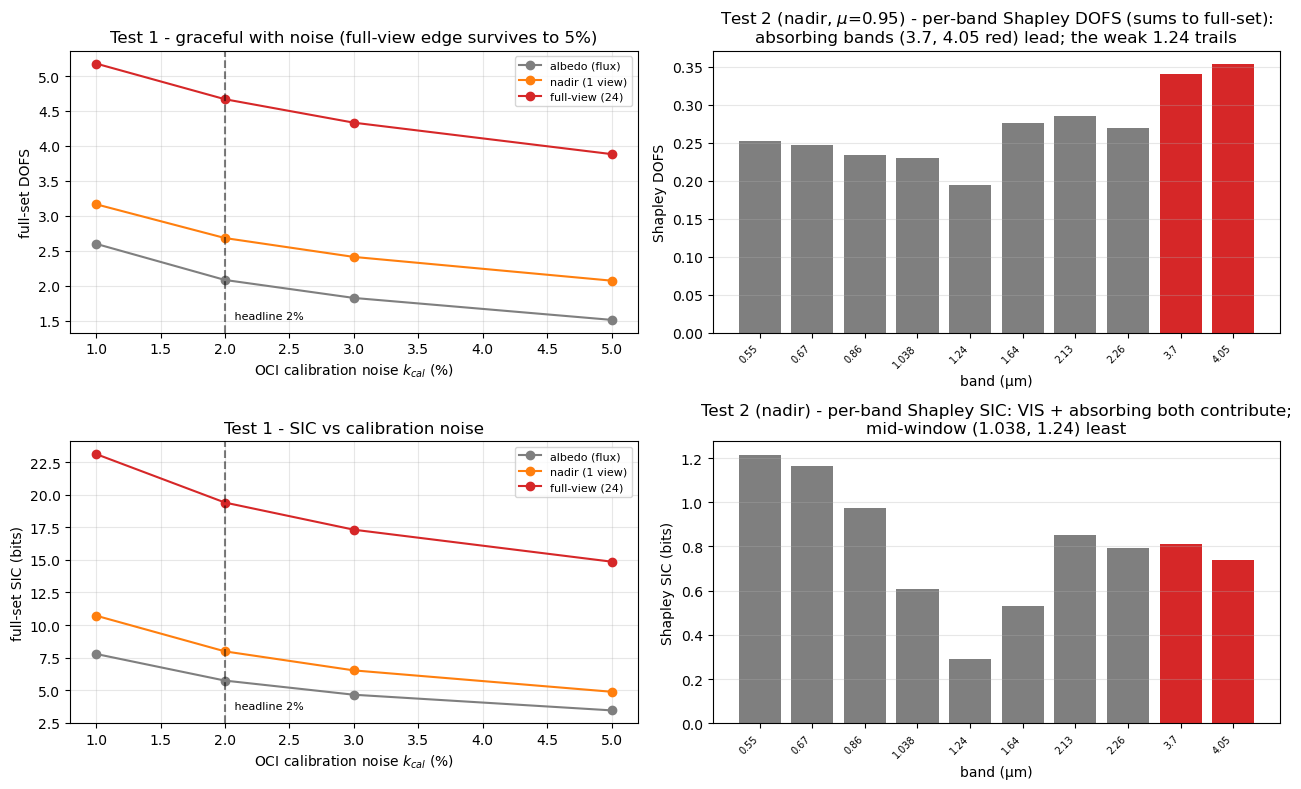

In [27]:
# Fig 6 - robustness: noise sweep [Test 1] + per-band SHAPLEY contribution [Test 2], DOFS (top) / SIC (bottom).
# Test 2 uses the superset-INDEPENDENT Shapley value (a band's fair share of the total — average marginal
# over all 2^n subsets; sums to the full-set DOFS/SIC) instead of the leave-one-out marginal (which
# under-credited mutually-redundant bands). Both Test-2 panels are nadir (1 view = mu=0.95).
ns = D['noise']; kc = ns['k_cal_pct']; bl = D['band_shapley']; labs = bl['labels']
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for row, met, yl1 in [(0, 'dofs', 'full-set DOFS'), (1, 'sic', 'full-set SIC (bits)')]:
    a = ax[row, 0]
    for k, c, lg in [('albedo', GREY, 'albedo (flux)'), ('nadir', ORA, 'nadir (1 view)'),
                     ('fullview', RED, 'full-view (24)')]:
        a.plot(kc, ns[f'{met}_{k}_mean'], 'o-', color=c, label=lg)
    lo, hi = a.get_ylim(); a.axvline(2.0, ls='--', c='k', alpha=.5)
    a.text(2.05, lo + .05 * (hi - lo), ' headline 2%', fontsize=8)
    a.set(xlabel=r'OCI calibration noise $k_{cal}$ (%)', ylabel=yl1); a.legend(fontsize=8); a.grid(alpha=.3)
    b = ax[row, 1]
    vals = np.array(bl[f'{met}_mean']); cols = ['tab:red' if l in ('3.7', '4.05') else GREY for l in labs]
    xb = np.arange(len(labs)); b.bar(xb, vals, color=cols)
    b.set_xticks(xb); b.set_xticklabels(labs, fontsize=7, rotation=45, ha='right')
    b.set(ylabel='Shapley ' + ('DOFS' if met == 'dofs' else 'SIC (bits)'), xlabel='band (µm)')
    b.grid(alpha=.3, axis='y')
ax[0, 0].set_title('Test 1 - graceful with noise (full-view edge survives to 5%)')
ax[1, 0].set_title('Test 1 - SIC vs calibration noise')
ax[0, 1].set_title('Test 2 (nadir, $\\mu$=0.95) - per-band Shapley DOFS (sums to full-set):\n'
                   'absorbing bands (3.7, 4.05 red) lead; the weak 1.24 trails')
ax[1, 1].set_title('Test 2 (nadir) - per-band Shapley SIC: VIS + absorbing both contribute;\n'
                   'mid-window (1.038, 1.24) least')
fig.tight_layout(); plt.show()

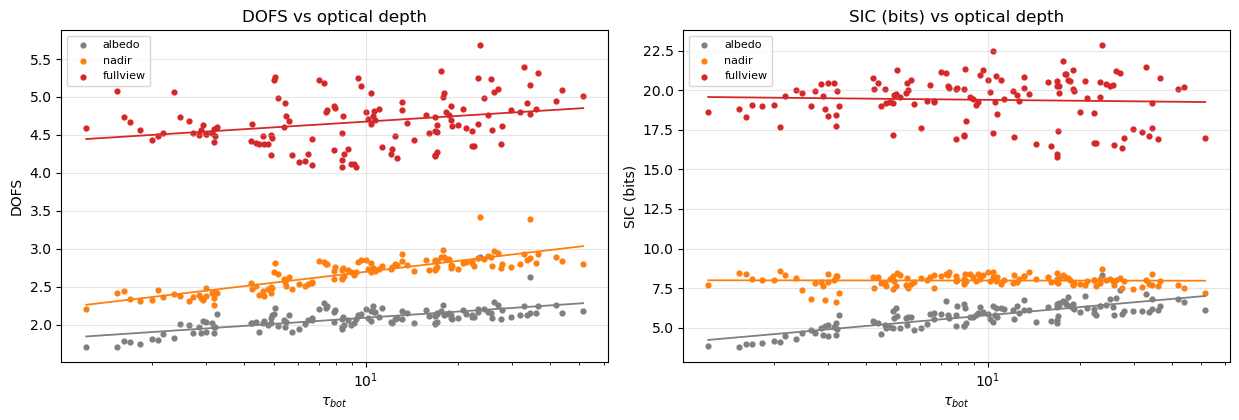

In [28]:
# Fig 4 - regime: DOFS & SIC vs optical depth (linear best-fit line per series; boxplot cut)
reg = D['regime']; tau = np.array([p['tau_bot'] for p in reg]); lt = np.log10(tau)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
for a, mt, yl in [(ax[0], 'dofs', 'DOFS'), (ax[1], 'sic', 'SIC (bits)')]:
    for k, c in [('albedo', GREY), ('nadir', ORA), ('fullview', RED)]:
        y = np.array([p[f'{mt}_{k}'] for p in reg]); a.scatter(tau, y, s=12, c=c, label=k)
        b = np.polyfit(lt, y, 1); xx = np.array([tau.min(), tau.max()])
        a.plot(xx, np.polyval(b, np.log10(xx)), c=c, lw=1.3)
    a.set(xlabel=r'$\tau_{bot}$', ylabel=yl, xscale='log', title=f'{yl} vs optical depth')
    a.grid(alpha=.3); a.legend(fontsize=8)
fig.tight_layout(); plt.show()

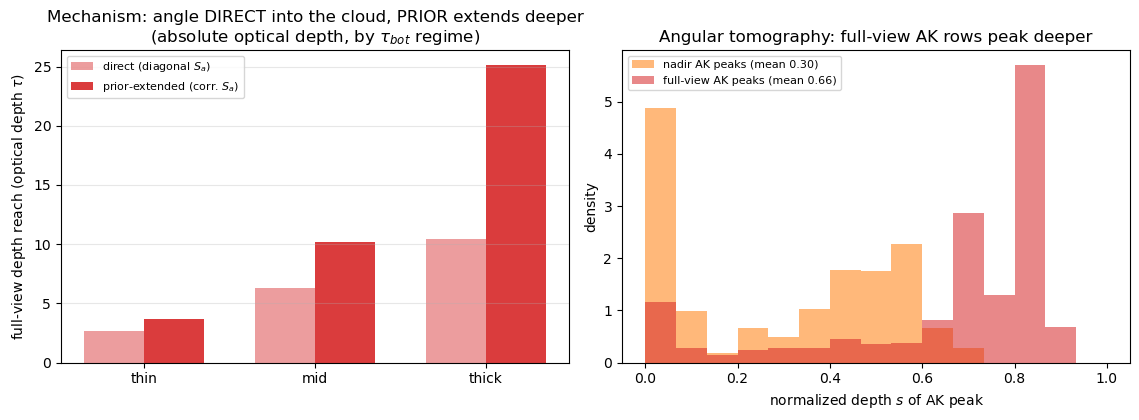

In [29]:
# Fig 5 - mechanism: direct (diagonal $S_a$) to mid-cloud, prior (correlated $S_a$) extrapolates to base
tauM = np.array([r['tau_bot'] for r in M]); q1, q2 = np.quantile(tauM, [1/3, 2/3])
regM = np.where(tauM < q1, 0, np.where(tauM < q2, 1, 2))
dep_tau = lambda k: np.array([r['depth'][k] * r['tau_bot'] for r in M])   # depth reach in optical depth
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3)); x = np.arange(3); w = .35
diag = [dep_tau('diag_fullview')[regM == i].mean() for i in range(3)]
corr = [dep_tau('corr_fullview')[regM == i].mean() for i in range(3)]
ax[0].bar(x - w/2, diag, w, label='direct (diagonal $S_a$)', color=RED, alpha=.45)
ax[0].bar(x + w/2, corr, w, label='prior-extended (corr. $S_a$)', color=RED, alpha=.9)
ax[0].set_xticks(x); ax[0].set_xticklabels(['thin', 'mid', 'thick'])
ax[0].set(ylabel=r'full-view depth reach (optical depth $\tau$)',
          title='Mechanism: angle DIRECT into the cloud, PRIOR extends deeper\n(absolute optical depth, by $\\tau_{bot}$ regime)')
ax[0].legend(fontsize=8, loc='upper left'); ax[0].grid(alpha=.3, axis='y')
akn = np.concatenate([np.array(r['ak_peak_nadir']) for r in M])
akf = np.concatenate([np.array(r['ak_peak_fullview']) for r in M]); bins = np.linspace(0, 1, 16)
ax[1].hist(akn, bins=bins, alpha=.55, color=ORA, density=True, label=f'nadir AK peaks (mean {akn.mean():.2f})')
ax[1].hist(akf, bins=bins, alpha=.55, color=RED, density=True, label=f'full-view AK peaks (mean {akf.mean():.2f})')
ax[1].set(xlabel=r'normalized depth $s$ of AK peak', ylabel='density',
          title='Angular tomography: full-view AK rows peak deeper')
ax[1].legend(fontsize=8); fig.tight_layout(); plt.show()

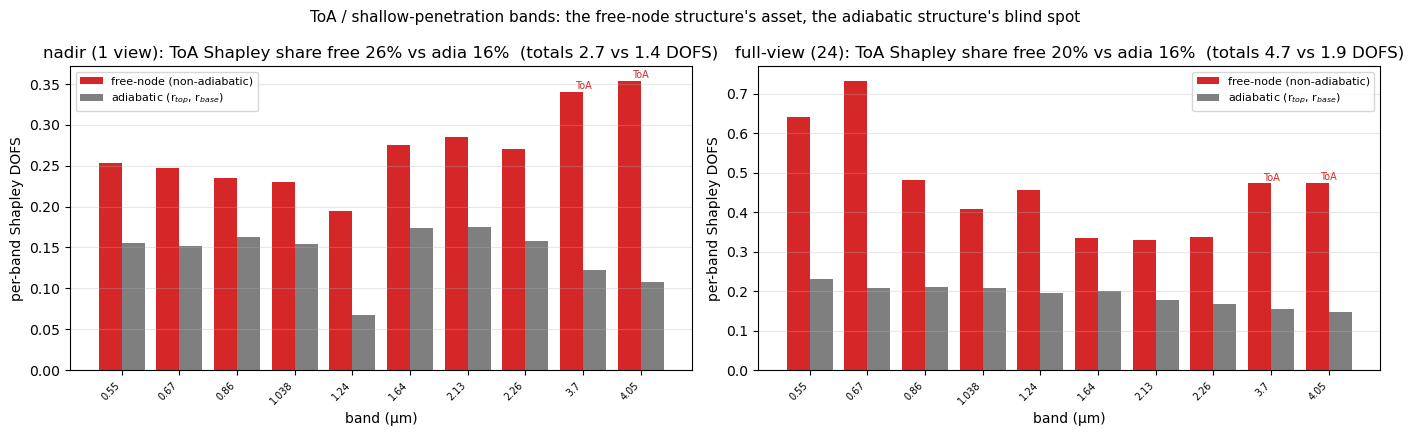

In [30]:
# Fig 7 - WHY the shallow / ToA bands matter: the free-node (non-adiabatic) r_e(τ) state USES them,
# a 2-param ADIABATIC (r_top, r_base) state barely does. Adiabatic Jacobian = cached K projected onto the
# adiabatic tangent ∂r_e(s)/∂(r_top,r_base); per-band SHAPLEY DOFS (fair, sums to total), free vs adiabatic.
ad = D['adiabatic']; labs = ad['labels']; xb = np.arange(len(labs)); w = 0.4
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for a, ctx, tag in [(ax[0], 'nadir', 'nadir (1 view)'), (ax[1], 'fullview', 'full-view (24)')]:
    c = ad[ctx]
    a.bar(xb - w/2, c['free_shapley'], w, color='tab:red', label='free-node (non-adiabatic)')
    a.bar(xb + w/2, c['adia_shapley'], w, color='tab:gray', label='adiabatic (r$_{top}$, r$_{base}$)')
    for i in ad['toa_idx']:
        a.annotate('ToA', (i, max(c['free_shapley'][i], c['adia_shapley'][i])), textcoords='offset points',
                   xytext=(0, 2), ha='center', fontsize=7, color='tab:red')
    a.set_xticks(xb); a.set_xticklabels(labs, fontsize=7, rotation=45, ha='right')
    a.set(ylabel='per-band Shapley DOFS', xlabel='band (µm)',
          title=f"{tag}: ToA Shapley share free {c['free_toa_share']:.0%} vs adia {c['adia_toa_share']:.0%}  "
                f"(totals {c['free_total']:.1f} vs {c['adia_total']:.1f} DOFS)")
    a.grid(alpha=.3, axis='y'); a.legend(fontsize=8)
fig.suptitle("ToA / shallow-penetration bands: the free-node structure's asset, the adiabatic structure's blind spot",
             fontsize=11)
fig.tight_layout(); plt.show()

**Findings — information content of the minimally-constrained $r_e(\tau)$ retrieval (125 VOCALS-REx profiles, 10-band instrument superset, NQuad=48, $\mu_0$=0.9; linearized at the LOO prior mean; OCI 2 % calibration noise). Bands are added in **data-greedy** order — at each step the band with the largest marginal nadir DOFS — so the curves show genuine diminishing returns (no hand-set ordering).**

1. **Spectral information saturates (verification).** Starting from the standard **bispectral baseline {0.67, 2.13}** (2 bands = the Nakajima–King method, 1.83 DOFS) and adding bands most-informative-first, nadir DOFS jumps to 2.29 (+4.05, the most-absorbing band) → 2.41 (+1.64) → 2.50 (+3.7) and then flattens to 2.68 (Fig 1). We deliberately do **not** pin a hard saturation point — the data-greedy curve plateaus *gradually* (illustratively, 95 % of the asymptote is reached by ~6 bands) — but the flattening itself is unambiguous. The band order is **data-greedy contextualised to the viewing geometry**, and it genuinely shifts with context: at **nadir** the absorbers rank first ($+$4.05$\to$1.64$\to$3.7), but at **full-view** the *penetrating / VIS* bands climb — 0.55 and 1.24 jump to bands 4–5 because multi-angle viewing unlocks them, pushing the absorbers to 6–7 (Fig 1 vs **Fig 1b**). The full-view DOFS saturates by the same $N_{\rm sat}$=7 (3.45 $\to$ 4.67; Fig 1b) — so *angle does not lower the number of bands needed*, it changes *which* bands matter and how much each is worth. The rise past the bispectral pair is carried by the **absorbing / SWIR bands {4.05, 1.64, 3.7}** — the data-greedy selection **independently picks the high-absorption bands NK1990 explored** (their 1.65, 3.70) plus the more-absorbing 4.05 µm right after the pair — and a 2nd strong absorber (4.05) carries a unique 0.11 DOFS beyond 3.7 (order-independent leave-one-out; Fig 6 Test 2). This is **penetration-depth diversity**, reproducing **CPV2012** spectral saturation qualitatively (SIC is the literature-comparable metric; absolute DOFS is parameterization-specific). *Per-band leave-one-out (Fig 6 Test 2): the VIS bands {0.55, 0.67} anchor $\tau$ but carry near-zero **unique** DOFS (mutually redundant), while the absorbing bands carry the unique vertical information; in SIC, however, the VIS bands do add precision — DOFS plateaus while SIC keeps climbing.*

2. **Angle adds information ON TOP of saturated spectral (the novel result) — but the angular gain itself saturates before the stream ceiling.** Across the **full 10-band set**, multi-angle radiance lifts DOFS 2.68 (nadir) → 4.76 (28 views) and pushes the penetration from $\tau\approx$9.4 to $\tau\approx$13.0 optical depths (Fig 2; deepest node with data-fraction$\geq$0.5, in absolute optical depth so thick clouds — small $s$, large $\tau$ — are not flattered). The increment is large but **angular-saturating**: 1→12 views adds **+1.55** DOFS, 12→24 only **+0.44**, and 24→28 just **+0.09** — ~95 % of the gain by **~20 views**, consistent with the NQuad=64 check (minimal IC past $N$=24). A *modest* number of views (HARP2's 10–60) captures essentially all of it. *(We treat 28 as the largest view count: 29–32 are TMS-extrapolated past the $N$=24 stream ceiling.)*

3. **Spectral ↔ angular overlap but are NOT fully interchangeable.** Iso-DOFS / iso-SIC contours run diagonal **pre-saturation** (trade bands $\leftrightarrow$ views) but turn vertical **post-saturation** (only views help; Fig 3 iso-lines); the angular gain $\Delta_{\rm ang}(b)=D(b,\text{full})-D(b,\text{nadir})$, plotted along the **full-view-greedy** band order (Fig 3b, right), **jumps when the complementary bands (0.55, 1.24) enter at bands 4–5** — they carry vertical spectral contrast that only oblique viewing resolves — then **plateaus at $\approx$2 DOFS**: the angular dimension's irreducible, non-interchangeable contribution, present even with the full saturated spectral set, that no number of co-located bands supplies. **The substitution is selective, and superset-independent (Fig 3b — Shapley *share* of the total, the fair attribution over all band subsets):** as views increase, angle is a *substitute* for the **absorbing** bands — 3.7 µm's share of the information *falls* 12.5 % → 9.8 % and 4.05 µm's *falls* 13.0 % → 9.9 % — but a *complement* to the **penetrating** 1.24 µm (share *rises* 7.4 % → 10.4 %). Crucially this is mainly a **DOFS (new-mode) effect**: the share shift is weaker in *SIC* (Fig 3b lower row), so angle's distinctive role is opening **new vertical modes**, not merely sharpening existing ones. Both absorbing bands and oblique views concentrate sensitivity near cloud top, so they overlap there; penetrating bands need angular diversity to resolve the profile.

4. **Direct to mid-cloud, prior-extrapolated to base.** Under a *diagonal* $S_a$ the angular field directly penetrates a roughly fixed optical depth (thin/mid/thick $\approx$ 2.7 / 6.3 / 10.5 $\tau$); the correlated (adiabatic) prior carries the rest to the base (3.7 / 10.2 / 25 $\tau$) — so the deep base of a thick cloud is **almost entirely prior-extrapolated** (Fig 5, left, now in optical depth). Full-view averaging-kernel rows peak deeper than nadir's (mean $s$ 0.30 → 0.66; Fig 5, right). The deep-base information is part measurement, part physically-justified prior — and the prior correlation length $\ell$ is what makes the deep-sensing bands redundant (their marginal IC is reclaimed under a weak prior; DESIGN §14). **Trying $\ell=\tau_{\rm bot}$ (the loo2x prior, double the default $\tau_{\rm bot}/2$) confirms this:** the headline IC barely moves (full-view DOFS 4.67 → 4.40 — robust to $\ell$), yet the deep-penetrating bands become *more* redundant — the per-band leave-one-out ratio of absorbing-to-penetrating contribution rises 1.71 → 2.17 — because a longer-correlated prior extrapolates the deep $r_e$ from the top over a greater depth.

5. **Robust to noise, linearization state, and prior strength.** **Noise (Test 1, Fig 6a):** full-view DOFS = 5.18 / 4.67 / 4.34 / 3.89 at 1 / 2 / 3 / 5 % calibration noise — graceful, with the $\approx$2-DOFS angular edge over nadir persisting at every level. **Prior / linearization:** full-view DOFS is stable across the LOO-prior-mean (4.67, headline), prior-realization draw (4.45), longer-correlation loo2x (4.40), and weak-prior (6.68) variants; the weak prior admits more DOFS but does not change the spectral-saturation / angular-on-top structure. $\tau_{\rm bot}$-known is a faithful upper bound (DESIGN §13).

6. **The shallow / ToA-sensing bands are an asset of the *non-adiabatic* structure (Fig 7).** Projecting the cached Jacobian onto a 2-parameter adiabatic state $(r_{\rm top}, r_{\rm base})$ and comparing per-band **Shapley DOFS**: the ToA bands {3.7, 4.05} command **26 % of the free-node structure's information but only 16 % of the adiabatic structure's** (nadir; 20 % vs 16 % at full-view), and they are the free-node's **most** valuable bands (Shapley 0.34 / 0.35, the two largest) yet only middling for the adiabatic. (Under the sharper leave-one-out marginal the contrast is starker still — 39 % vs 7 %.) Physically, the ToA bands' information is *near-top vertical structure*: the free-node state resolves it, while the adiabatic law slaves the top to $r_{\rm top}$ + the smooth curve, so the fine ToA signal is wasted. **The shallow-penetration bands earn their keep *because* the retrieval is minimally constrained** — a direct motivation for the non-adiabatic framing. (The linearisation point is the adiabatic prior mean, so the projection is exact there; computed at the LOO prior, nadir + full-view.)

**Per-band attribution = Shapley value (Figs 3b, 6, 7).** Every single-band IC number is a **Shapley value** — the band's average marginal contribution over *all* $2^{10}$ band subsets — the unique *fair, superset-independent* attribution; it **sums to the total DOFS/SIC**, so the per-band bars are a genuine decomposition. The two single-coalition alternatives are biased: the '9→10' leave-one-out *under*-credits mutually-redundant bands (each VIS band $\approx$0 because another VIS band substitutes for it), while the '0→1' standalone *over*-credits the $\tau$/column anchor (every band $\approx$1 DOF alone). Computed exactly via a fast $S_\varepsilon$-diagonal DOFS/SIC evaluator (verified identical to the full posterior); the conclusions are *sharper but identical in direction* under leave-one-out.

**Reading SIC and DOFS together.** We report both because they answer different questions. **DOFS $=\sum_i s_i^2/(1+s_i^2)=\mathrm{tr}(A)$** saturates at 1 per mode — it counts *how many* independent vertical pieces the measurement resolves (and, via the averaging kernels, *where*). **SIC $=\tfrac12\sum_i\log_2(1+s_i^2)$** is unbounded — it measures *how much* total uncertainty is removed (bits), weighting well-measured modes. The two diagnose different gains:

- **DOFS plateaus while SIC keeps climbing** (e.g. the band sweep past $N_{\rm sat}$, Fig 1): the extra channels are *sharpening already-resolved $r_e$ modes*, not opening new ones. Where **both** rise (the multi-angle sweep, Fig 2) genuinely **new vertical modes** are being resolved — so the two curves *together* separate new-dimension gains from precision gains.
- **SIC is the literature-comparable metric** (CPV2012 reports the Shannon information of cloud albedo); the absolute DOFS count is specific to our free-node $r_e(\tau)$ parameterization, so DOFS + the averaging kernels carry the **vertical-resolution** story while SIC carries the cross-study comparison.
- **In the interchangeability test** (Fig 3), contrast $\Delta_{\rm ang}$ in DOFS (new modes) vs in SIC (added precision): post-saturation, angle adds DOFS (new vertical modes) where extra bands add mostly SIC (precision on existing modes) — the cleanest statement of what the angular dimension uniquely contributes on top of saturated spectral.